# 3.3  Análisis de vocabulario para períodos a comparar

* Explorar frecuencias de palabras: Filtrado por frecuencia mínima. 

* Vocabulario: Medir qué proporción del vocabulario permanece activo (por encima del umbral de frecuencia) en los tres períodos.

* Identificar palabras emergentes: detectar palabras que aparecen o aumentan significativamente su uso en un período respecto a otro.

Paper:
2014 - Detección estadísticamente significativa de cambios lingüísticos : Plantea enfoque computacional para rastrear y detectar cambios lingüísticos estadísticamente significativos en el significado y el uso de las palabras. Preguntas: ¿Qué tan estadísticamente significativo es el cambio en el uso de una
palabra w a lo largo del tiempo (en T (w))?. Dado que una palabra ha cambiado, ¿en qué momento ocurrió el
cambio?



## Consideraciones previas
### Preprocesamiento de texto para la generación de corpus
* En base a las 33097 proyectos de ley entre período parlamentario [127 a 141] o  [03/2009 - 02/2024]

#### Normalización
Antes de desarrollar los enfoques de detección de cambio semánticos, con el objetivo de mejorar la calidad semántica del análisis, se aplicó un proceso de normalización sobre los títulos de proyecto de ley. Este procedimiento incluyó :

* Eliminar  caracteres como puntos, comas, comillas, espacios, brackets, etc.
* Convertir los números a su equivalente a palabras.
* Convertir a minúsculas.
* Lematizar.
* Remover stopwords.

**Limpieza de términos dominantes**

Dado el carácter jurídico y político del los títulos, se identificó presencia de términos de dominio legislativo, particularmente se tuvo en cuenta los asociados a proyectos de ley, que si bien frecuentes no aportan valor semántico específico al análisis temático sobre salud. Se implementó un filtro de n-gramas más frecuentes (n=2 a n=5).

Un n-grama es una secuencia de n elementos consecutivos de un texto o discurso. Los elementos pueden ser palabras, números, símbolos, fonemas, sílabas, letras, o pares de bases. 


Los n-gramas más frecuentes (n=2 a n=5) a eliminar por dominio :

    * 'ley modificacion articulo', 
    * 'incorporacion articulo bis',
    * 'contrato trabajo ley',
    * 'modificacion articulo',
    * 'ley modificacion',
    * 'reproduccion expediente',
    * 'codigo penal',
    * 'articulo bis',
    * 'incorporacion articulo',
    * 'modificacion ley',
    * 'contrato trabajo', 
    * 'trabajo ley'

Estas frases o combinaciones de palabras fueron eliminados del los títulos buscando preservar aquellas palabras con contenido temático relevante para el análisis semántico en salud. Esta estrategia constribuye a reducir el ruido y a mejorar la estabilidad y expresividad de los embeddings entrenados por período, aunque también afecta la cantidad de tokens en el corpus y los modelos de lenguaje a aplicar.


**Vocabulario**

Lista única de todas las palabras (o tokens) presentes en un conjunto de textos



## Proyecto de ley de salud para período parlamentario entre 127 a 141
* 2848 iniciativas legislativas 

**Tokens**
* Cant_token: promedio	19.25, std	10.00, min	2, mediana	18, max 125
* Cant_token_normalizado: promedio	9.76,	std 4.65,	min 1, mediana 9, max 50


**De títulos normalizados**

N-gramas más frecuentes top 6 (mas diferencia con el resto). Se observa n-gramas de n entre 2 a 5 con mínima frecuencia 1: 
	
  ngram  frecuencia
* 37700                        programa nacional         208
* 27461                       medico obligatorio         187
* 37658              programa medico obligatorio         153
* 37657                          programa medico         153
* 32016                          obligatorio pmo         150
* 27500                   medico obligatorio pmo         150
* 37678          programa medico obligatorio pmo         128
* 28193                         ministerio salud         123
* 2417                         ambito ministerio         123
* 2430                   ambito ministerio salud         113
* 43176                             salud nacion         105

**VOCABULARIO**

Palabras más frecuentes

* 3221 palabrás únicas. En promedio 8.63 veces de ocurrencia en título, mediana 2 veces. Se identifica palabras con frecuencias extremas.
    * Rango: [1 - 836] 
    * Desviación estándar: 31.12 veces. Es decir, las mayor parte de las frecuencias de palabras de la muestra tienden a estar lejos de su media, se extienden sobre un rango de valores más amplio.
    * Top 5 palabras con mayores frecuencias:  nacional (836), creacion (628), programa (488), regimen	(485), salud (483). 


**Resumen**
* Duración: 15 periodos parlamentarios - 127 a 141
* Períodos: 5 períodos parlamentarios
* Total palabras: 29.841 # 27806
* Vocabulario: 3221
* Dominio: proyectos de ley de salud argentina (iniciativas)


## 1. EDA

In [1]:
# Importar librerias

from dotenv import load_dotenv
import os
import pandas as pd
import numpy as np
import pickle
import sweetviz as sv
import sys

# Visualización
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.lines import Line2D
import matplotlib.colors as mcolors
from matplotlib import colormaps

from collections import Counter
from itertools import islice

from tqdm import tqdm
tqdm.pandas()

In [2]:
import datetime
print(datetime.datetime.now().strftime("%Y%m%d%H%M"))

202603221415


In [3]:
# Configurar path
load_dotenv() # Cargar las variables de entorno del archivo .env
BASE_DIR =  os.getenv("DIR_BASE")
RESULTADOS_DIR = os.getenv("DIR_DATOS_PROCESADOS") # Acceder a las variables de entorno
sys.path.append(BASE_DIR)
sys.path.append(RESULTADOS_DIR)

pd.set_option('display.max_colwidth', None)

In [4]:
# Abrir
with open(RESULTADOS_DIR + 'base_texto_df_ley_0924.pkl', 'rb') as file: 
    basetexto_df = pickle.load(file)

basetexto_df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Proyecto.ID,33097,33097,HCDN152173,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título,33097,31392,JUICIO POR JURADOS. CREACION.,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título procesado,33097,27969,contrato de trabajo ley numero modificacion del articulo numero sobre licencias especiales,33,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Título normalizado,33097,27247,licencia especial,36,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Cant_token,33097.0,NaN,NaN,NaN,21.181225,10.774979,2.0,14.0,19.0,27.0,125.0
Cant_token_procesados,33097.0,NaN,NaN,NaN,20.947971,10.805237,2.0,13.0,19.0,27.0,128.0
Cant_token_normalizado,33097.0,NaN,NaN,NaN,9.782246,5.081133,0.0,6.0,9.0,12.0,57.0
Proyecto_SALUD,33097.0,NaN,NaN,NaN,0.08605,0.280442,0.0,0.0,0.0,0.0,1.0
Resultado,33097,6,NO TUVO TRATAMIENTO POSTERIOR NI DICTAMEN,32191,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Periodo,33097.0,NaN,NaN,NaN,134.111944,4.075721,127.0,131.0,134.0,137.0,141.0


In [5]:
# Seleccionando IL de Salud
basetexto_df = basetexto_df[basetexto_df['Proyecto_SALUD']==1]
print("Conj. de datos de proyecto_SALUD con Nan en Período:",basetexto_df.shape)
basetexto_df = basetexto_df[~basetexto_df['Periodo'].isna()]
print("Conj. de datos de proyecto_SALUD sin Nan en Período:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD con Nan en Período: (2848, 12)
Conj. de datos de proyecto_SALUD sin Nan en Período: (2848, 12)


In [6]:
basetexto_df = basetexto_df[~(basetexto_df['Título normalizado']==" ")]
print("Conj. de datos de proyecto_SALUD sin título vacio:",basetexto_df.shape)

Conj. de datos de proyecto_SALUD sin título vacio: (2848, 12)


In [7]:
basetexto_df[['Cant_token','Cant_token_normalizado']].describe()

,Cant_token,Cant_token_normalizado
count,2848.000000,2848.000000
mean,19.251053,9.766854
std,10.004802,4.657696
min,2.000000,1.000000
25%,12.000000,6.000000
50%,18.000000,9.000000
75%,24.000000,12.000000
max,125.000000,50.000000


In [8]:
basetexto_df['Periodo_5anios'] = 2009 # el período parlamentario  127 inicia el 01/03/2009
basetexto_df.loc[(basetexto_df['Periodo']>=132) & (basetexto_df['Periodo']<137), 'Periodo_5anios'] =  2014 # 132 inicia el 01/03/2014
basetexto_df.loc[(basetexto_df['Periodo']>=137), 'Periodo_5anios'] =  2019 # 137 inicia el 01/03/2019 

Cantidad de tokens por títulos

In [9]:
basetexto_df.groupby('Periodo_5anios')['Cant_token_normalizado'].describe()

,count,mean,std,min,25%,50%,75%,max
Periodo_5anios,,,,,,,,
2009,776.0,10.146907,5.136241,2.0,7.0,9.0,13.0,50.0
2014,1009.0,9.648167,4.301405,2.0,6.0,9.0,12.0,28.0
2019,1063.0,9.602070,4.604169,1.0,6.0,9.0,12.0,34.0


## 2. Analizando frecuencias de palabras por período 
Se tiene en cuenta los períodos parlamentaríos


In [10]:
# LECTURA OBJETO PARA DETECTAR CAMBIOS SEMANTICOS
with open(RESULTADOS_DIR + 'periodo_5anios_df.pkl', 'rb') as file: 
    PER5anios_df = pickle.load(file)

In [11]:
freqs_list = []
for anios5 in PER5anios_df['Periodo_5anios'].to_list():
    print(anios5)
    subdf = PER5anios_df.loc[(PER5anios_df['Periodo_5anios']==anios5),]
    subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")                                 
    
    freqs = Counter()
    subdf['Título normalizado'].apply(lambda x: freqs.update(x.split())) # cualquier espacio.
    total_number = sum(freqs.values())
    print('Número total de tokens:', total_number)

    freqs_df = pd.DataFrame.from_dict(freqs, orient='index',
                                      columns=['Frecuencia'])
    freqs_df = freqs_df.reset_index()

    freqs_df = freqs_df.rename(columns={'index': 'Palabra'})
    mask = (freqs_df['Palabra'].str.len() > 1)
    print(freqs_df.shape)
    freqs_df = freqs_df.loc[mask]
    print(freqs_df.shape)
    print('Entradas removidas de 1 carácter.')
    print('Cantidad de tokens únicos:', freqs_df.shape[0])

    freqs_df = freqs_df.sort_values('Frecuencia').reset_index(drop=True)

    freqs_df['Porcentaje'] = freqs_df['Frecuencia'] / total_number

    
    freqs_df.to_csv(RESULTADOS_DIR+'./archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_'+str(anios5)+'.csv', index=False)

    freqs_df['Período'] = str(anios5)
    
    freqs_list.append(freqs_df)
    

2009
Número total de tokens: 7872
(1717, 2)
(1717, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1717
2014
Número total de tokens: 9731
(1969, 2)
(1969, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1969
2019
Número total de tokens: 10203
(1876, 2)
(1876, 2)
Entradas removidas de 1 carácter.
Cantidad de tokens únicos: 1876


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\1285124620.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\1285124620.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  subdf['Título normalizado'] = subdf['Título normalizado'].str.replace("."," ")
C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\1285124620.py:5: SettingWithCopyWarning: 
A value is trying to be set on a 

In [12]:
freqs_df = pd.concat(freqs_list) # Dataframe de frecuecias

In [13]:
freqs_df.head(2)

,Palabra,Frecuencia,Porcentaje,Período
0,xii,1,0.000127,2009
1,ipod,1,0.000127,2009


### Análisis general (Tres Periodos Combinados)

In [14]:
vocab_periodo = freqs_df['Período'].value_counts().reset_index() # vocabulario por períodos de 5 años
vocab_periodo

,Período,count
0,2014,1969
1,2019,1876
2,2009,1717


In [15]:
# Período 2009: Periodos parlamentarios 127-131 (03/2009 - 02/2014)
# Período 2014: Periodos parlamentarios 132-136 (03/2014 - 02/2019)
# Período 2019: Periodos parlamentarios 137-141 (03/2019 - 02/2024)
period_dict = {
        2009: '127-131\n[03/2009 - 02/2014]',
        2014: '132-136\n[03/2014 - 02/2019]',
        2019: '137-141\n[03/2019 - 02/2024]'
    }

def periodos_a_fechas(periodo):
    if periodo in period_dict:
        return f'{periodo}\n{period_dict[periodo]}'
    return ''

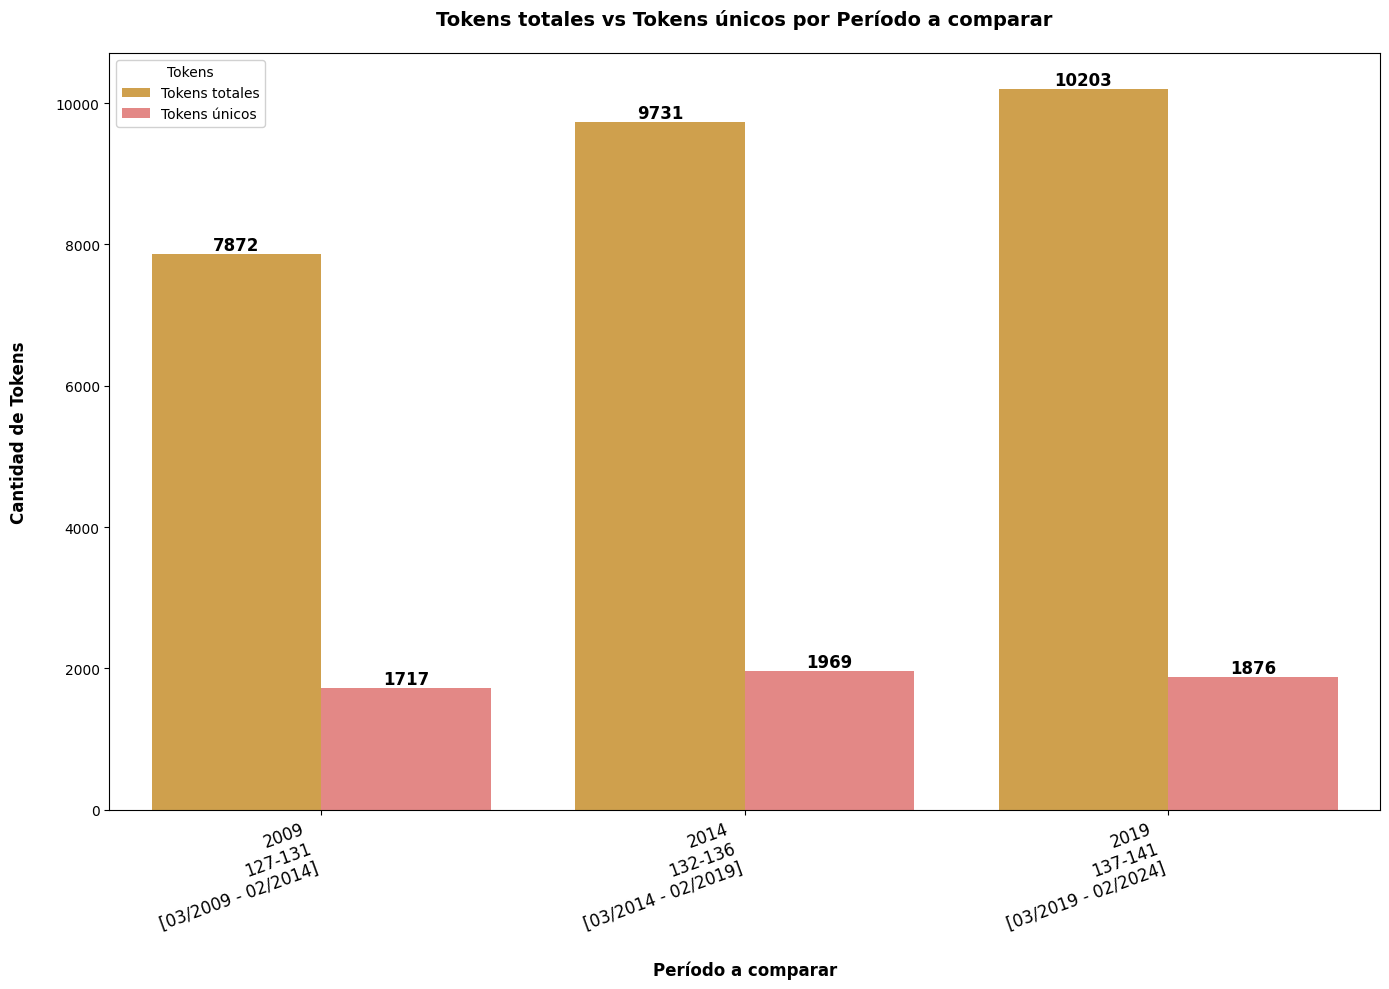

In [16]:
def grafico_barras_agrupadas(freqs_df):
    # Calcular métricas
    tokens_totales = freqs_df.groupby('Período')['Frecuencia'].sum()
    tokens_unicos = freqs_df.groupby('Período')['Palabra'].count()
    
    # Crear DataFrame para plotting
    df_plot = pd.DataFrame({
        'Período a comparar': tokens_totales.index,
        'Tokens totales': tokens_totales.values,
        'Tokens únicos': tokens_unicos.values
    })
    
    # Convertir a formato largo para seaborn
    df_melted = df_plot.melt(id_vars='Período a comparar', 
                            value_vars=['Tokens totales', 'Tokens únicos'],
                            var_name='Tipo', 
                            value_name='Cantidad')
    
    # Crear gráfico
    fig, ax = plt.subplots(figsize=(14, 10))
    
    sns.barplot(data=df_melted, x='Período a comparar', y='Cantidad', hue='Tipo', 
                palette=['#DE8F05', '#F15854'], ax=ax, alpha=0.8)
     # Configurar eje x
    xticks = sorted(df_melted['Período a comparar'].unique())
    xtick_labels = [periodos_a_fechas(int(x)) for x in xticks]
   
    ax.set_xticks(xticks)
    ax.set_xticklabels(xtick_labels, rotation=20, ha='right', fontsize=12)
    
    # Configuraciones
    ax.set_title('Tokens totales vs Tokens únicos por Período a comparar', 
                fontsize=14, fontweight='bold', pad=20)
    ax.set_xlabel("Período a comparar", fontsize=12, fontweight='bold', labelpad=20)
    ax.set_ylabel("Cantidad de Tokens", fontsize=12, fontweight='bold', labelpad=20)
    #ax.tick_params(axis='x', rotation=20)
    
    # Añadir valores en las barras
    for container in ax.containers:
        ax.bar_label(container, fmt='%d', fontweight='bold', fontsize=12)
    
    # Mover leyenda
    ax.legend(title='Tokens', loc='upper left', framealpha=0.9)
    
    plt.grid(False)
    plt.tight_layout()
    plt.savefig(BASE_DIR + "imagenes/barras_agrupadas_tokens.png")
    plt.show()

# Usar
grafico_barras_agrupadas(freqs_df)

In [17]:
vocab_periodo.describe() # Estadística

,count
count,3.000000
mean,1854.000000
std,127.432335
min,1717.000000
25%,1796.500000
50%,1876.000000
75%,1922.500000
max,1969.000000


In [18]:
# Calculo la media de cantidad de palabras del vocabulario
from scipy import stats

n = len(vocab_periodo['count'])
media_total = np.mean(vocab_periodo['count'])

# Calcula la desviación estándar de los promedios anuales
desviacion_estandar = np.std(vocab_periodo['count'], ddof=1) # ddof=1 para desviación estándar de la muestra

# Calcula el Error Estándar de la Media (SEM)
sem = desviacion_estandar / np.sqrt(n)
print('media de vocabulario por periodo (cantidad de palabras únicas)',media_total)
print('desviacion_estandar', desviacion_estandar)
coeficiente_variacion = (desviacion_estandar / media_total) * 100
print('coeficiente_variacion ',coeficiente_variacion)
print('sem',sem)

# Calcula el Intervalo de Confianza del 95%
alpha = 0.05  # Nivel de significancia
grados_libertad = n - 1
valor_critico_t = stats.t.ppf(1 - alpha / 2, grados_libertad)
intervalo_confianza = valor_critico_t * sem
print("intervalo de confianza: ",intervalo_confianza)

media de vocabulario por periodo (cantidad de palabras únicas) 1854.0
desviacion_estandar 127.43233498606232
coeficiente_variacion  6.873372976594514
sem 73.57309290766565
intervalo de confianza:  316.5594690313555


La desviación estándar es de 127 palabras, el Coeficiente de Variación de 7 (dispersión relativa), lo que indica que los vocabularios o las cantidades de palabras únicas por período están más dispersas, la media 1854 no es tan representativa para los tres periodos a procesar.

In [19]:
freqs_df = freqs_df.sort_values(by = 'Frecuencia', ascending =False)

In [20]:

freqs_df.to_csv(RESULTADOS_DIR+'/archivos_out/frec_para_datos_limpios_por_desplaz_semantico_anios5_all.csv', index=False)


In [21]:
# Suponiendo que tu DataFrame se llama 'df'
print("--- Análisis del Vocabulario para los períodos comparados ---")

# 1. Tamaño total del vocabulario único
vocabulario_total = freqs_df['Palabra'].nunique()
print(f"Tamaño total del vocabulario único en los tres periodos: {vocabulario_total}")

# 2. Frecuencia total de todas las palabras
frecuencia_total = freqs_df['Frecuencia'].sum()
print(f"Frecuencia total de todas las palabras en los tres periodos: {frecuencia_total}")


--- Análisis del Vocabulario para los períodos comparados ---
Tamaño total del vocabulario único en los tres periodos: 3221
Frecuencia total de todas las palabras en los tres periodos: 27806


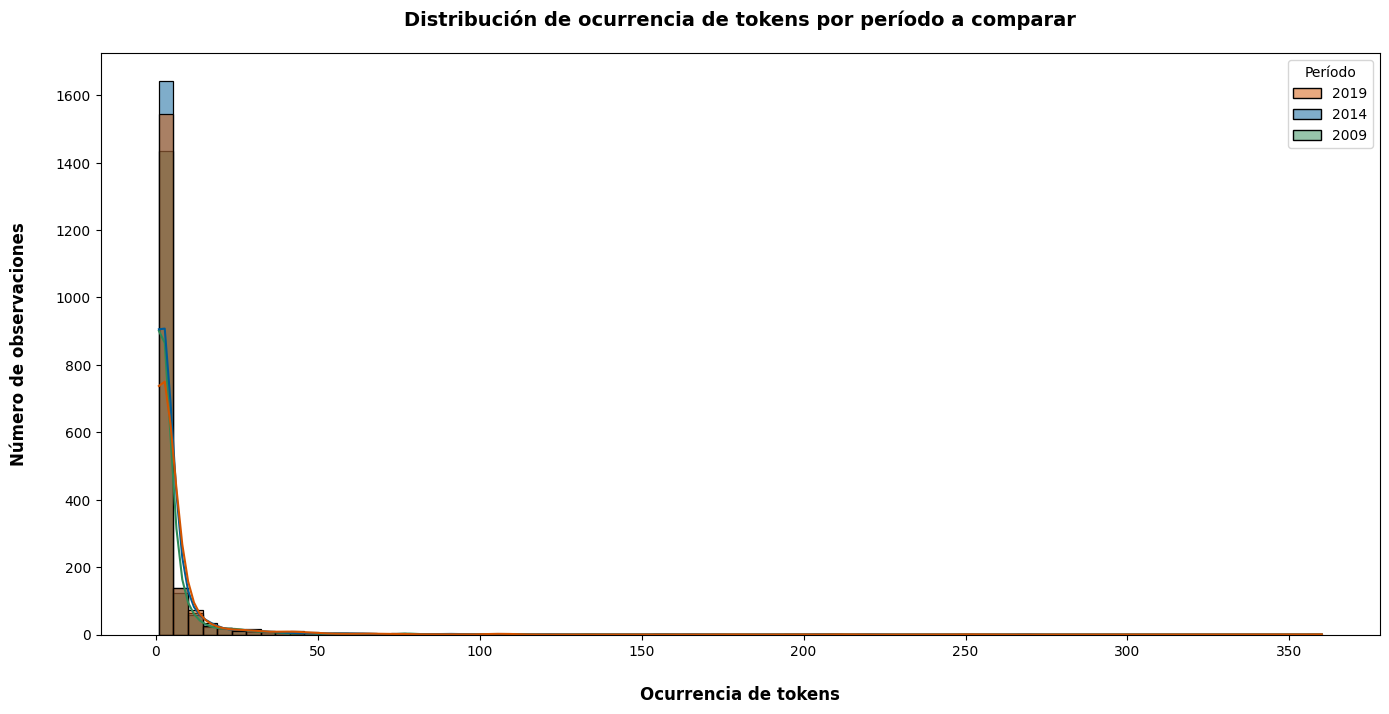

In [22]:
# 3. Distribución de la frecuencia de las palabras
verde_salud = '#2E8B57'      # Verde principal (conservado)
azul_medico = '#005C97'       # Azul más oscuro para mejor contraste
ambar_accesible = '#D35400'   # Ámbar/naranja oscuro distinguible


plt.figure(figsize=(14,8))
sns.histplot(freqs_df, x='Frecuencia', bins=80, hue='Período', kde=True, palette=[ambar_accesible, azul_medico,verde_salud])
plt.title('Distribución de ocurrencia de tokens por período a comparar',fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Ocurrencia de tokens',fontsize=12, 
              fontweight='bold', 
              labelpad=20)
plt.ylabel('Número de observaciones',fontsize=12, 
              fontweight='bold', 
              labelpad=20)
# Ajustar layout
plt.tight_layout()
plt.subplots_adjust(bottom=0.2)
# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/distribucionFrec_periodo.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')
plt.show()


<Axes: xlabel='Frecuencia'>

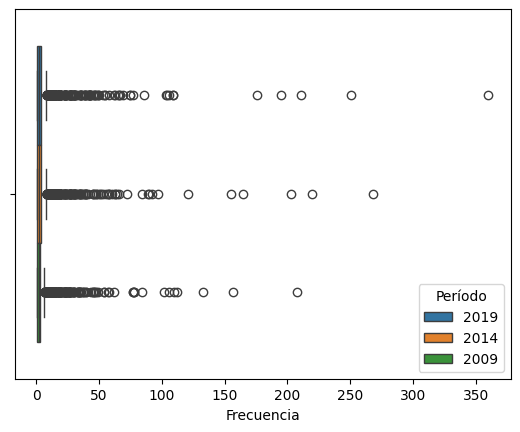

In [23]:
sns.boxplot(x = 'Frecuencia', data=freqs_df, hue='Período')

In [24]:
rango = np.max(freqs_df['Frecuencia']) - np.min(freqs_df['Frecuencia'])
coeficiente_variacion = (desviacion_estandar / freqs_df['Frecuencia'].mean()) * 100
print('Rango ',rango)
print('Coeficiente_variacion ',coeficiente_variacion)


Rango  359
Coeficiente_variacion  2549.0133323472583


Existe un alta variabilidad de frecuencia de palabra en período de 5 años (rango = 359 frecuencia). La mayorías de las palabras en período de 5 años tienen baja frecuencia de ocurrencia tal que se concentran alrededor de frecuencia=2. El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 4. 

In [25]:
def eliminar_outliers_iqr(df, columna):
    """
    Separa los outliers y devuelve dos DataFrames:
    - df_limpio: sin outliers
    - df_outliers: con los valores atípicos detectados

    Parámetros:
    df (pd.DataFrame): DataFrame de pandas
    columna (str): Nombre de la columna a analizar

    Retorna:
    df_limpio (pd.DataFrame): DataFrame sin outliers
    df_outliers (pd.DataFrame): DataFrame solo con outliers
    """
    Q1 = df[columna].quantile(0.25)
    Q3 = df[columna].quantile(0.75)
    IQR = Q3 - Q1

    # Definir los límites
    limite_inferior = Q1 - 1.5 * IQR
    limite_superior = Q3 + 1.5 * IQR
    print("Q1:",Q1)
    print("Q3:",Q3)
    print('limite_inferior:', limite_inferior)
    print('limite_superior:', limite_superior)


    # Filtrar datos
    df_limpio = df[(df[columna] >= limite_inferior) & (df[columna] <= limite_superior)]
    df_outliers = df[(df[columna] < limite_inferior) | (df[columna] > limite_superior)]

    return df_limpio, df_outliers    


In [26]:
# Detectar outliers
freqs_limpio_df , outliers_df = eliminar_outliers_iqr(freqs_df, 'Frecuencia')
display("Outliers detectados:\n", outliers_df)

Q1: 1.0
Q3: 4.0
limite_inferior: -3.5
limite_superior: 8.5


'Outliers detectados:\n'

,Palabra,Frecuencia,Porcentaje,Período
1875,nacional,360,0.035284,2019
1968,nacional,268,0.027541,2014
1874,creacion,251,0.024601,2019
1967,creacion,220,0.022608,2014
1873,programa,211,0.020680,2019
...,...,...,...,...
1552,forma,9,0.001143,2009
1553,hospital,9,0.001143,2009
1554,ganancia,9,0.001143,2009
1555,tabaquismo,9,0.001143,2009


Se considera que una palabra en periodo de 5 años con frecuencia superior 8 es una palabra de frecuencia extrema o especial.

In [27]:
print("Cantidad de palabras únicas por período que superan las 8 veces en alguno de los tres períodos  - OUTLIERS:", len(outliers_df.Palabra.unique()))

Cantidad de palabras únicas por período que superan las 8 veces en alguno de los tres períodos  - OUTLIERS: 315


* Existe un alta variabilidad de frecuencia de palabra en período de 5 años (rango = 359 frecuencia).
* La mayoría de las palabras en período de 5 años tienen baja frecuencia de ocurrencia tal que se  concentran alrededor de frecuencia=2. 
* El 75% del total de palabras en los tres periodos presentan una frecuencia inferior a frecuencia = 4.
* Se considera que una palabra en período de 5 años con frecuencia superior 8 es una palabra de frecuencia extrema o especial. 
* Hay 315 palabras únicas por período que superan las 8.5 veces en alguno de los tres períodos. 
* Total de palabras con frecuencia extrema en alguno de los tres periodo = 622 


### Análisis de los períodos a comparar 

In [28]:
from scipy.stats import bootstrap


# Para una primera aproximación y visualización de la incertidumbre, el bootstrap de percentiles (o la salida por defecto de scipy.stats.bootstrap) es un buen comienzo.
def confidence_intervals(data):
    res = bootstrap((data,), np.mean, confidence_level=0.95, random_state=42) # Añadimos random_state para reproducibilidad
    return (res.confidence_interval.low, res.confidence_interval.high)

def confidence_intervals_bca(data):
    """
    Calcula el intervalo de confianza del 95% para la media utilizando el método BCa bootstrap.
    """
    res = bootstrap((data,), np.mean, confidence_level=0.95, method='BCa', random_state=42)
    return (res.confidence_interval.low, res.confidence_interval.high)




Bootstrap de Percentiles (Percentile Bootstrap):

Cómo funciona: El intervalo de confianza se construye tomando los percentiles apropiados (por ejemplo, el 2.5% y el 97.5% para un intervalo del 95%) de la distribución de las estadísticas bootstrap.
Ventajas: Conceptualmente simple y fácil de entender.
Desventajas: Su precisión puede ser limitada, especialmente con muestras pequeñas o distribuciones sesgadas. No siempre es transformacionalmente invariante (el intervalo de confianza para una función del parámetro no siempre es la función de los límites del intervalo de confianza).


--- Análisis por Periodo ---

--- Periodo: 2009 ---
Tamaño del vocabulario único: 1717
Total de tokens: 7872


,Frecuencia,Porcentaje
count,1717.000000,1717.000000
mean,4.584741,0.000582
std,11.508913,0.001462
min,1.000000,0.000127
25%,1.000000,0.000127
50%,2.000000,0.000254
75%,3.000000,0.000381
max,208.000000,0.026423


Frecuencia media de las palabras (BCa): 4.58 (IC 95%: 4.12, 5.23)
['nacional' 'creacion' 'salud' 'programa' 'social' 'regimen' 'ley'
 'obligatorio' 'medico' 'declarar']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
1716,nacional,208,0.026423,2009
1715,creacion,157,0.019944,2009
1714,salud,133,0.016895,2009
1713,programa,112,0.014228,2009
1712,social,110,0.013974,2009
1711,regimen,106,0.013465,2009
1710,ley,102,0.012957,2009
1709,obligatorio,84,0.010671,2009
1708,medico,78,0.009909,2009
1707,declarar,78,0.009909,2009


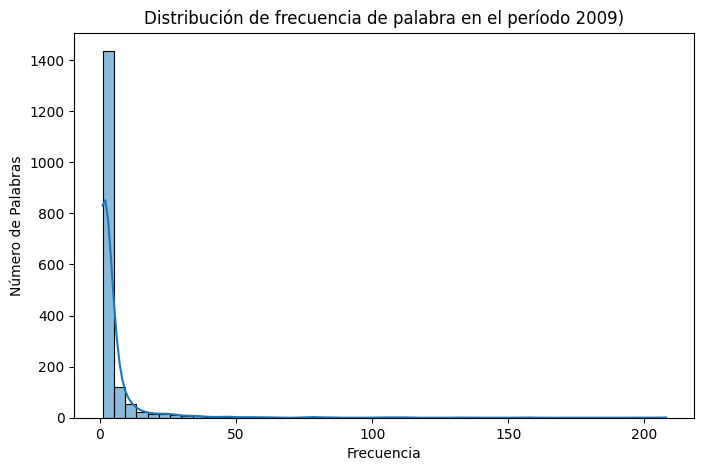


--- Periodo: 2014 ---
Tamaño del vocabulario único: 1969
Total de tokens: 9731


,Frecuencia,Porcentaje
count,1969.000000,1969.000000
mean,4.942103,0.000508
std,13.561801,0.001394
min,1.000000,0.000103
25%,1.000000,0.000103
50%,2.000000,0.000206
75%,4.000000,0.000411
max,268.000000,0.027541


Frecuencia media de las palabras (BCa): 4.94 (IC 95%: 4.44, 5.66)
['nacional' 'creacion' 'regimen' 'programa' 'salud' 'medico' 'obligatorio'
 'social' 'persona' 'tratamiento']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
1968,nacional,268,0.027541,2014
1967,creacion,220,0.022608,2014
1966,regimen,203,0.020861,2014
1965,programa,165,0.016956,2014
1964,salud,155,0.015928,2014
1963,medico,121,0.012434,2014
1962,obligatorio,97,0.009968,2014
1961,social,92,0.009454,2014
1960,persona,90,0.009249,2014
1959,tratamiento,89,0.009146,2014


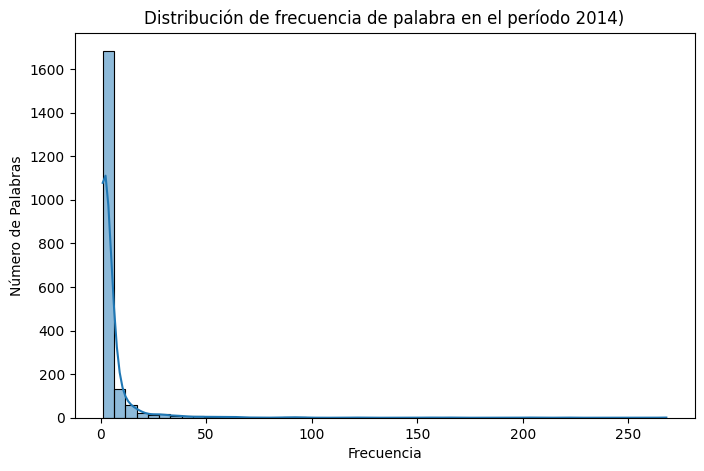


--- Periodo: 2019 ---
Tamaño del vocabulario único: 1876
Total de tokens: 10203


,Frecuencia,Porcentaje
count,1876.000000,1876.000000
mean,5.438699,0.000533
std,16.027975,0.001571
min,1.000000,0.000098
25%,1.000000,0.000098
50%,2.000000,0.000196
75%,4.000000,0.000392
max,360.000000,0.035284


Frecuencia media de las palabras (BCa): 5.44 (IC 95%: 4.84, 6.34)
['nacional' 'creacion' 'programa' 'salud' 'regimen' 'medico' 'persona'
 'obligatorio' 'covid' 'integral']


'Top 10 palabras'

,Palabra,Frecuencia,Porcentaje,Período
1875,nacional,360,0.035284,2019
1874,creacion,251,0.024601,2019
1873,programa,211,0.020680,2019
1872,salud,195,0.019112,2019
1871,regimen,176,0.017250,2019
1869,medico,109,0.010683,2019
1870,persona,109,0.010683,2019
1868,obligatorio,106,0.010389,2019
1867,covid,104,0.010193,2019
1866,integral,103,0.010095,2019


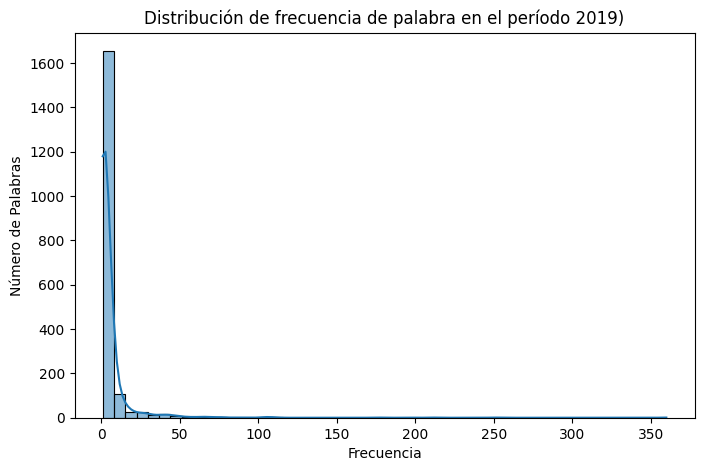

In [29]:
print("\n--- Análisis por Periodo ---")
for periodo in ['2009','2014','2019']:

    df_periodo = freqs_df[freqs_df['Período'] == periodo]
    print(f"\n--- Periodo: {periodo} ---")

    # 1. Tamaño del vocabulario único por periodo
    vocabulario_periodo = df_periodo['Palabra'].nunique()
    print(f"Tamaño del vocabulario único: {vocabulario_periodo}")

    # 2. Frecuencia total de palabras por periodo
    frecuencia_total_periodo = df_periodo['Frecuencia'].sum()
    print(f"Total de tokens: {frecuencia_total_periodo}")
    display(df_periodo.describe())

    # 3. Frecuencia media de las palabras por periodo con intervalos de confianza bootstrap
    frecuencias_periodo = df_periodo['Frecuencia'].values
    if len(frecuencias_periodo) > 0:
  
        media_frecuencia = np.mean(frecuencias_periodo)
        intervalo_confianza = confidence_intervals_bca(frecuencias_periodo)
        # Esto nos da una idea del rango plausible para la verdadera frecuencia media de las palabras en ese periodo.
        print(f"Frecuencia media de las palabras (BCa): {media_frecuencia:.2f} (IC 95%: {intervalo_confianza[0]:.2f}, {intervalo_confianza[1]:.2f})")

        temp = df_periodo.sort_values('Frecuencia', ascending=False)
        print(temp.head(10).Palabra.unique())
        display("Top 10 palabras",temp.head(10))

        
        # Visualización de la distribución de frecuencias por periodo
        plt.figure(figsize=(8, 5))
        sns.histplot(df_periodo['Frecuencia'], bins=50, kde=True)
        plt.title(f'Distribución de frecuencia de palabra en el período {periodo})')
        plt.xlabel('Frecuencia')
        plt.ylabel('Número de Palabras')
        plt.show()
    else:
        print("No hay palabras en este periodo.")




* Frecuencia media con intervalos de confianza: el promedio de ocurrencias de una palabra en el periodo, es en general, un frecuencia de ocurrencia igual a 5. 
* El intervalo de confianza te proporciona un rango dentro del cual es probable que se encuentre la verdadera frecuencia media de las palabras en la población 
(todos los posibles títulos de ese periodo). Los intervalos de confianza para el promedio de ocurrencias de una palabra en el periodo para diferentes periodos en general no se superponen, se observa para el periodo 2019 una frecuencia media de 6.


In [30]:
def pares_primer_paso(lista_items):
    return [(lista_items[i],lista_items[i+1]) for i in range(len(lista_items)-1)]
pares_periodos = pares_primer_paso(['2009','2014','2019'])
pares_periodos

[('2009', '2014'), ('2014', '2019')]

In [31]:
from matplotlib_venn import venn2,venn3


print("\n--- Palabras en común entre pares de peróodos ---")

for par in pares_periodos:
    periodo1 = par[0]
    periodo2 = par[1]
    vocabulario1 = set(freqs_df[freqs_df['Período'] == periodo1]['Palabra'])
    vocabulario2 = set(freqs_df[freqs_df['Período'] == periodo2]['Palabra'])
    palabras_en_comun = vocabulario1.intersection(vocabulario2)
    union = len(vocabulario1.union(vocabulario2))
    total = len(vocabulario1) + len(vocabulario2)
    
    num_comunes = len(palabras_en_comun)
    print(f"\nPalabras en común entre {periodo1} y {periodo2}: {num_comunes}")
    print(total, union)
    print("%",round((num_comunes/union)*100,3))
    print(list(palabras_en_comun)[1:10])




--- Palabras en común entre pares de peróodos ---

Palabras en común entre 2009 y 2014: 1083
3686 2603
% 41.606
['juvenil', 'psicomotricista', 'requisito', 'activo', 'justicia', 'numerir', 'habitat', 'pronin', 'actividad']

Palabras en común entre 2014 y 2019: 1130
3845 2715
% 41.621
['procedimiento', 'embarazo', 'abordaje', 'fructosa', 'requisito', 'reeducacion', 'activo', 'numerir', 'actividad']


In [32]:
(41.606+41.621)/2 # media

41.6135

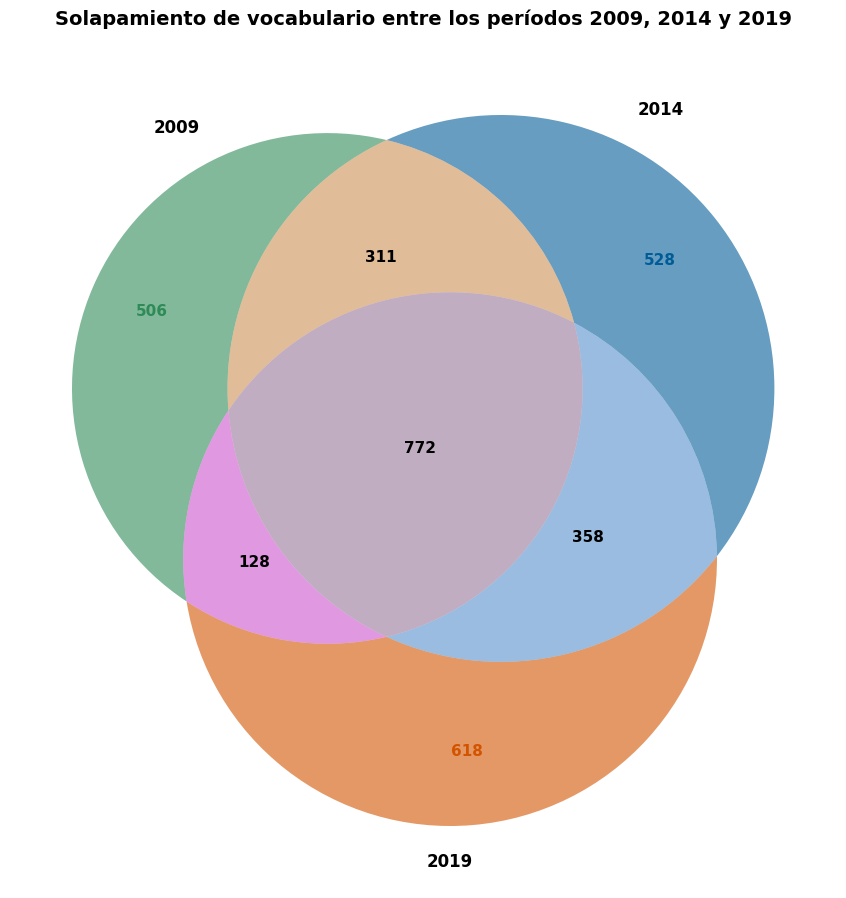

In [33]:
# PALETA ACCESIBLE PARA SALUD - CERTIFICADA WCAG AA
verde_salud = '#2E8B57'      # Verde principal (conservado)
azul_medico = '#005C97'       # Azul más oscuro para mejor contraste
ambar_accesible = '#D35400'   # Ámbar/naranja oscuro distinguible

plt.figure(figsize=(14, 10))
vocabulario1 = set(freqs_df[freqs_df['Período'] == '2009']['Palabra'])
vocabulario2 = set(freqs_df[freqs_df['Período'] == '2014']['Palabra'])
vocabulario3 = set(freqs_df[freqs_df['Período'] == '2019']['Palabra'])

v = venn3([vocabulario1, vocabulario2, vocabulario3], set_labels=('2009', '2014', '2019'))

# Asignar colores ACCESIBLES
v.get_patch_by_id('100').set_facecolor(verde_salud)      # 2009
v.get_patch_by_id('100').set_alpha(0.6)

v.get_patch_by_id('010').set_facecolor(azul_medico)      # 2014  
v.get_patch_by_id('010').set_alpha(0.6)

v.get_patch_by_id('001').set_facecolor(ambar_accesible)  # 2019
v.get_patch_by_id('001').set_alpha(0.6)

# Opcional: colores de etiquetas
v.get_label_by_id('100').set_color(verde_salud)
v.get_label_by_id('010').set_color(azul_medico)
v.get_label_by_id('001').set_color(ambar_accesible)

# Aumentar tamaño de los valores numéricos (intersecciones)
for label_id in ['100', '010', '001', '110', '101', '011', '111']:
    label = v.get_label_by_id(label_id)
    if label:
        label.set_fontsize(11)      
        label.set_fontweight('bold')

for text in v.set_labels:
    text.set_fontsize(12)
    text.set_fontweight('bold')

plt.title('Solapamiento de vocabulario entre los períodos 2009, 2014 y 2019' ,pad=20, fontsize=14, fontweight="bold")
# Ajustar layout
plt.tight_layout()
# Dejar espacio arriba para que no choque con el título
plt.subplots_adjust(top=0.85)

# Guardar en alta calidad para accesibilidad
plt.savefig(BASE_DIR+'imagenes/ven_vocabularioPeriodo.png', 
            dpi=300, bbox_inches='tight', 
            facecolor='white', edgecolor='none')

plt.show()

Palabras en común: El número de palabras en común y los diagramas de Venn muestran la superposición del vocabulario entre los diferentes periodos. 
En general, 42% del vocabulario total de pares de periodos a comparar es compartido, es decir  que solo el 29% de las palabras únicas que aparecen en la unión de los vocabularios de ambos periodos están presentes en ambos periodos. El 58% restante del vocabulario total aparece solo en uno de los dos periodos comparados.


Influencia en Vocabularios Pequeños:

En vocabularios pequeños, un solapamiento del 42% puede tener un impacto significativo en el análisis de cambio semántico:

* Menos palabras para comparar: Cuanto menor sea el solapamiento, menor será el conjunto de palabras para las cuales puedes directamente intentar detectar un cambio semántico comparando su uso o representaciones a través del tiempo.

* Mayor impacto de palabras nuevas y desaparecidas: Un porcentaje considerable del vocabulario siendo nuevo en un periodo o desapareciendo del otro puede indicar cambios temáticos o en el foco del discurso, lo cual podría estar relacionado con cambios semánticos en las palabras compartidas. Sin embargo, también dificulta el análisis directo del cambio semántico para las palabras no compartidas.

* Potencial para inestabilidad en modelos: Si intentas entrenar modelos de embedding o de lenguaje en vocabularios pequeños con bajo solapamiento, la falta de datos compartidos puede llevar a representaciones inestables o poco confiables para las palabras.
En resumen, un solapamiento del 29% en un vocabulario pequeño sugiere que hay una discontinuidad considerable en el léxico utilizado entre los periodos comparados, lo que puede dificultar la detección robusta de cambios semánticos utilizando métodos que se basan en la comparación directa de representaciones de palabras compartidas.

#### Palabras emergentes

* Objetivo: detectar palabras que aparecen o aumentan significativamente su uso en un período respecto a otro.

Técnicas comunes:

* Comparación de frecuencias relativas entre períodos : z-score, log-odds ratio con prior.

* TF-IDF por período: resalta palabras distintivas en un segmento temporal.

In [34]:
Vocab_periodo_df =  pd.pivot_table(freqs_df, values=['Frecuencia'], columns=['Período'],
                      index=['Palabra']).reset_index()

Vocab_periodo_df.columns = [col[1] if col[1] else col[0] for col in Vocab_periodo_df.columns]
Vocab_periodo_df.fillna(0, inplace=True) # Rellenar valores faltantes con 0
Vocab_periodo_df

,Palabra,2009,2014,2019
0,1a1,0.0,2.0,0.0
1,1a2,0.0,2.0,0.0
2,abastecimiento,0.0,0.0,2.0
3,abdominal,0.0,1.0,0.0
4,abierto,0.0,2.0,4.0
...,...,...,...,...
3216,zonal,1.0,0.0,0.0
3217,zoonosis,0.0,3.0,1.0
3218,zoonotica,1.0,1.0,0.0
3219,zooterapia,1.0,0.0,0.0


**Calcular diferencias y Z-Score para identificar emergentes**

Las puntuaciones z, estandarizadas por media y desviación estándar de la matriz de entrada a.
https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.zscore.htmlm

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

def calcular_diferencia_zscore(df, periodo1, periodo2, min_frecuencia=5):
    """
    Calcula la diferencia de frecuencia normalizada (Z-Score de la diferencia)
    para identificar palabras emergentes entre dos periodos.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'palabra', 'frecuencia', 'porcentaje', 'periodo'.
        periodo1 (int): Primer periodo para la comparación.
        periodo2 (int): Segundo periodo para la comparación.
        min_frecuencia (int): Frecuencia mínima en al menos uno de los periodos para considerar la palabra.

    Returns:
        pd.DataFrame: DataFrame con palabras compartidas, sus frecuencias en ambos periodos,
                      diferencia de frecuencia y Z-Score de la diferencia.
    """
    df1 = df[df['Período'] == periodo1].set_index('Palabra')[['Frecuencia', 'Porcentaje']].add_suffix(f'_{periodo1}')
    df2 = df[df['Período'] == periodo2].set_index('Palabra')[['Frecuencia', 'Porcentaje']].add_suffix(f'_{periodo2}')

    df_comparacion = pd.concat([df1, df2], axis=1, join='outer').fillna(0)

    # Filtrar palabras con baja frecuencia en ambos periodos
    df_comparacion = df_comparacion[
        (df_comparacion[f'Frecuencia_{periodo1}'] >= min_frecuencia) |
        (df_comparacion[f'Frecuencia_{periodo2}'] >= min_frecuencia)
    ]

    df_comparacion['Diferencia_frecuencia'] = df_comparacion[f'Frecuencia_{periodo2}'] - df_comparacion[f'Frecuencia_{periodo1}']
    df_comparacion['zscore_diferencia'] = zscore(df_comparacion['Diferencia_frecuencia'])

    return df_comparacion.sort_values(by='zscore_diferencia', ascending=False)

def visualizar_palabras_emergentes(df_resultados, top_n=20, title="Palabras emergentes (Z-Score diferencia)"):
    """
    Visualiza las N palabras con el Z-Score de diferencia más alto.

    Args:
        df_resultados (pd.DataFrame): DataFrame con la columna 'zscore_diferencia'.
        top_n (int): Número de palabras a mostrar.
        title (str): Título del gráfico.
    """
    top_emergentes = df_resultados.head(top_n).sort_values(by='zscore_diferencia', ascending=True)
    plt.figure(figsize=(14, 8))
    sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')
    plt.title(title)
    plt.xlabel("Z-Score de la diferencia de frecuencia")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()



--- Comparación entre 2009 y 2014 ---
Cantidad de palabras emergentes, Z > 1.5 : 18


,Frecuencia_2009,Porcentaje_2009,Frecuencia_2014,Porcentaje_2014,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
regimen,106.0,0.013465,203.0,0.020861,97.0,8.716825
creacion,157.0,0.019944,220.0,0.022608,63.0,5.576998
nacional,208.0,0.026423,268.0,0.027541,60.0,5.299955
programa,112.0,0.014228,165.0,0.016956,53.0,4.653520
persona,46.0,0.005843,90.0,0.009249,44.0,3.822389
medico,78.0,0.009909,121.0,0.012434,43.0,3.730041
alimento,29.0,0.003684,63.0,0.006474,34.0,2.898911
sistema,26.0,0.003303,58.0,0.005960,32.0,2.714215
pmo,35.0,0.004446,66.0,0.006782,31.0,2.621867


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\3124845849.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


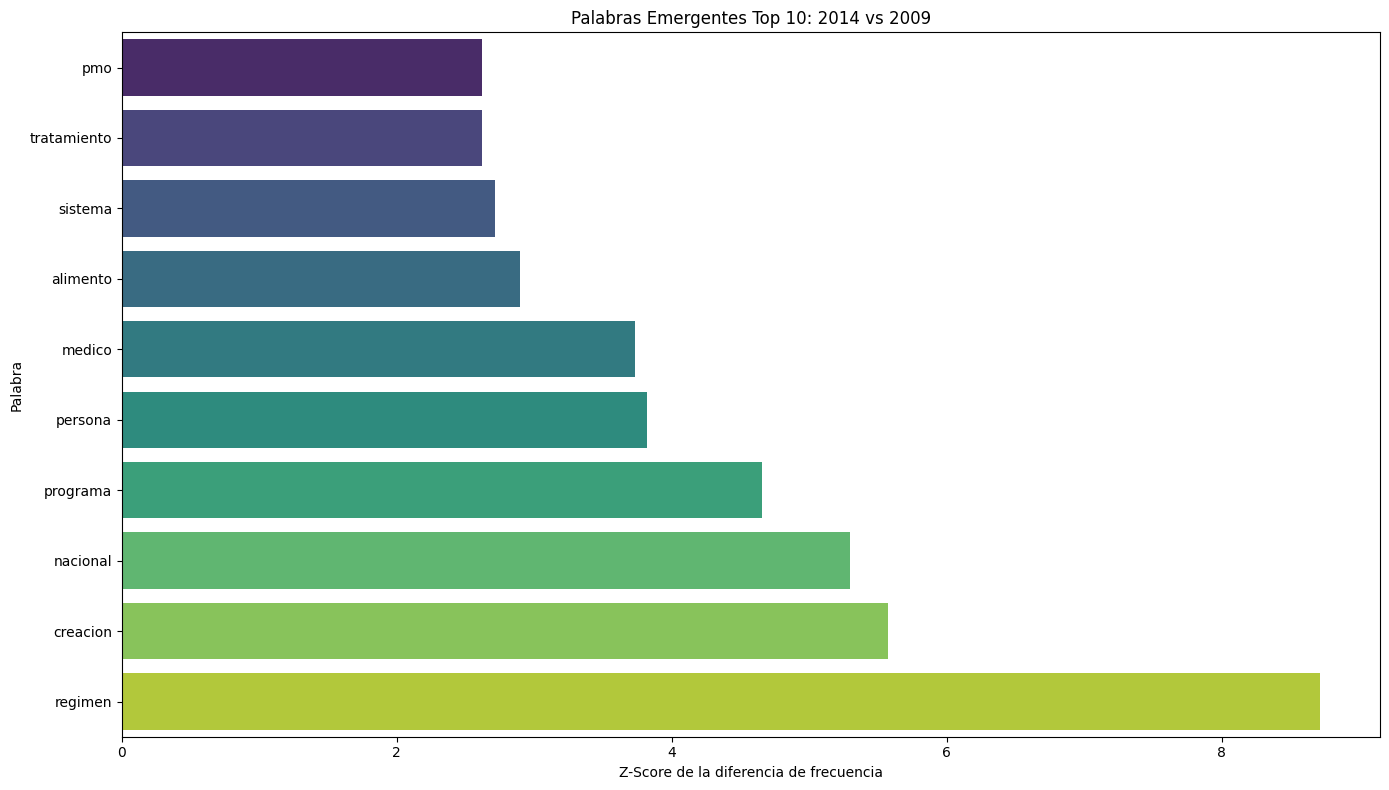


--- Comparación entre 2014 y 2019 ---
Cantidad de palabras emergentes, Z > 1.5 : 24


,Frecuencia_2014,Porcentaje_2014,Frecuencia_2019,Porcentaje_2019,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
covid,0.0,0.000000,104.0,0.010193,104.0,9.441082
nacional,268.0,0.027541,360.0,0.035284,92.0,8.338943
integral,48.0,0.004933,103.0,0.010095,55.0,4.940681
crear,0.0,0.000000,53.0,0.005195,53.0,4.756992
pandemia,0.0,0.000000,47.0,0.004606,47.0,4.205922
programa,165.0,0.016956,211.0,0.020680,46.0,4.114077
salud,155.0,0.015928,195.0,0.019112,40.0,3.563008
sanitario,27.0,0.002775,63.0,0.006175,36.0,3.195628
creacion,220.0,0.022608,251.0,0.024601,31.0,2.736403


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\3124845849.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


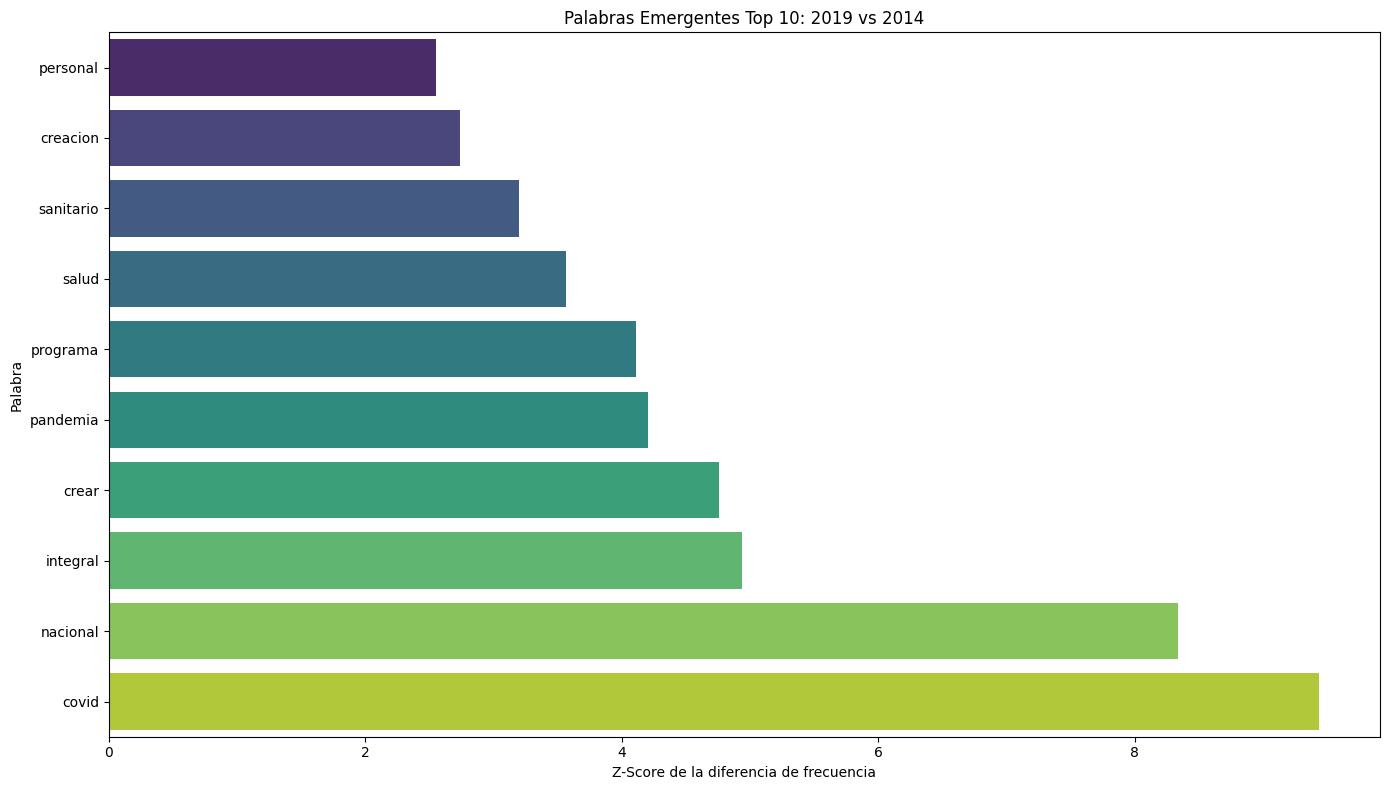


--- Comparación entre 2009 y 2019 ---
Cantidad de palabras emergentes, Z > 1.5 : 24


,Frecuencia_2009,Porcentaje_2009,Frecuencia_2019,Porcentaje_2019,Diferencia_frecuencia,zscore_diferencia
Palabra,,,,,,
nacional,208.0,0.026423,360.0,0.035284,152.0,9.583692
covid,0.0,0.000000,104.0,0.010193,104.0,6.481536
programa,112.0,0.014228,211.0,0.020680,99.0,6.158395
creacion,157.0,0.019944,251.0,0.024601,94.0,5.835254
integral,26.0,0.003303,103.0,0.010095,77.0,4.736574
regimen,106.0,0.013465,176.0,0.017250,70.0,4.284176
persona,46.0,0.005843,109.0,0.010683,63.0,3.831778
salud,133.0,0.016895,195.0,0.019112,62.0,3.767150
crear,0.0,0.000000,53.0,0.005195,53.0,3.185496


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\3124845849.py:49: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='zscore_diferencia', y=top_emergentes.index, data=top_emergentes, palette='viridis')


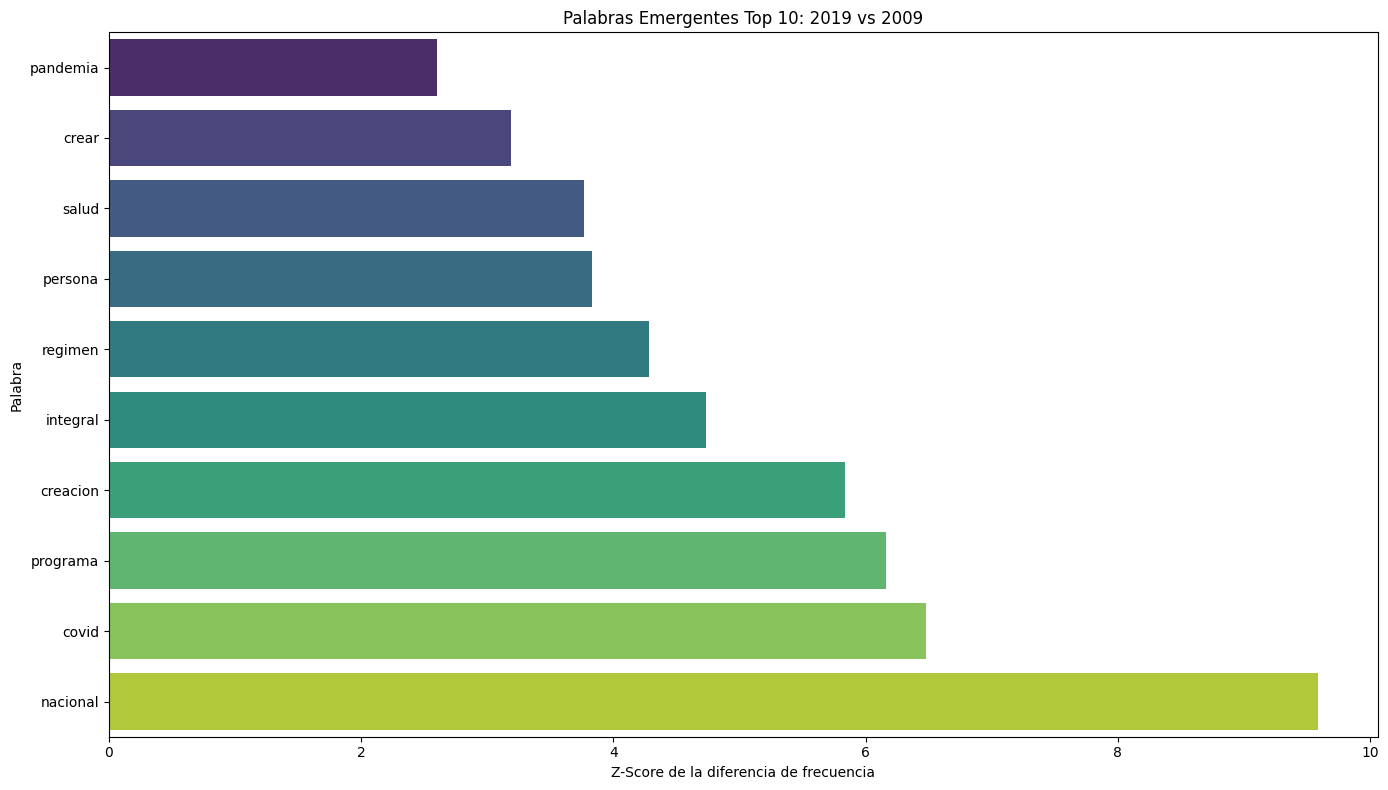

In [36]:
periodo_pares = [('2009', '2014'), ('2014', '2019'), ('2009', '2019')]

for p1, p2 in periodo_pares:
    print(f"\n--- Comparación entre {p1} y {p2} ---")
    resultados = calcular_diferencia_zscore(freqs_df.copy(), p1, p2, min_frecuencia=5)
    resultados.to_csv(RESULTADOS_DIR+'/archivos_out/zscore_'+p1+'_'+p2+'.csv')
    emergentes = resultados[resultados['zscore_diferencia']>1.5]
    print("Cantidad de palabras emergentes, Z > 1.5 :",len(emergentes))
    display(emergentes.head(10))  # Mostrar las 10 palabras más emergentes
    visualizar_palabras_emergentes(emergentes,10, title=f"Palabras Emergentes Top 10: {p2} vs {p1}")


El Z-Score estandariza la diferencia, permitiendo comparar la magnitud del cambio relativa a la variabilidad de todas las diferencias. Un Z-Score positivo alto sugiere una mayor emergencia en el segundo periodo. Se consideraron emergentes aquellas palabras con un z-score superior a 1.5, es decir, cuyo crecimiento superó en al menos 1.5 desviaciones estándar el crecimiento promedio del conjunto. Este umbral permite detectar términos que se destacan significativamente sin restringir el análisis a casos extremos.

* Se observan palabras de alta frecuencia con Z-Scores extremos, tal que están presentes en los tres períodos. Por ejemplo "nacional" y "programa", "creacion" son palabras con alta frecuencia y Z-scores extremos entre los períodos .
La altas frecuencia podrían hacer que sus representaciones en el espacio de embedding estén más "anclada", dominen el proceso de aprendizaje. 

* La palabra "covid" presenta un Z-scores extremos entre los períodos comparados 2014 y 2019, esto es porque tiene solo aparición en el periodo para 2019. Lo cual tiene sentido porque entre esos años se dio la pandemia.

Fortalezas y debilidades del enfoque en palabras con baja frecuencia y poco Vocabulario Compartido:

Fortalezas:

* Simple y directo: El cálculo de la diferencia de frecuencia y el Z-Score son relativamente sencillos de implementar y entender.

* Identifica cambios relativos: El Z-Score ayuda a identificar palabras cuyo cambio de frecuencia es grande en comparación con la variabilidad general de los cambios de frecuencia en el vocabulario compartido. 

Debilidades:

Problemas con palabras de baja frecuencia:

Ruido: Las palabras que aparecen con muy poca frecuencia pueden tener grandes cambios relativos en su porcentaje o frecuencia debido a una sola aparición o desaparición. Estos cambios pueden generar Z-Scores altos pero no ser semánticamente significativos o robustos. El umbral min_frecuencia intenta mitigar esto, pero elegir el umbral adecuado puede ser difícil.

Estimaciones inestables: Las estadísticas basadas en conteos bajos pueden ser inestables y sensibles a pequeñas fluctuaciones en los datos.
Problemas con poco vocabulario compartido:

Análisis limitado: El enfoque solo puede analizar las palabras que están presentes en ambos periodos comparados. Ignora las palabras que emergen completamente en un periodo o desaparecen del otro, las cuales podrían ser indicadores importantes de cambio semántico o temático.

Sesgo en la comparación: Si el vocabulario compartido es pequeño y no representativo de los cambios lingüísticos generales, las conclusiones basadas en él podrían estar sesgadas.

##### log-odds ratio (con o sin prior bayesiano) 
https://www.cambridge.org/core/journals/political-analysis/article/fightin-words-lexical-feature-selection-and-evaluation-for-identifying-the-content-of-political-conflict/81B3703230D21620B81EB6E2266C7A66
file:///C:/Users/Usuario/iamas_iniciativasleg_salud/papers/fightin-words-lexical-feature-selection-and-evaluation-for-identifying-the-content-of-political-conflict.pdf

El log-odds ratio compara la probabilidad de que una palabra aparezca en un corpus A (ej. 2019–2023) frente a un corpus B (ej. 2009–2013). Cuanto más alta (positiva) sea la puntuación, más característica o "emergente" es la palabra en A. Si es muy negativa, es distintiva de B.
Fue propuesto y difundido por Monroe et al. (2008) en análisis político y por Eisenstein et al. (2014) para redes sociales.

Corrige el ruido de palabras que aparecen muy poco. Es más confiable que mirar frecuencias absolutas o proporc crudas. Permite comparar muchos términos de forma estadísticamente sólida incluso en corpus pequeños. 

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

def calcular_log_odds_ratio_apriori(frecuencia_periodo1, total_tokens_periodo1,
                                    frecuencia_periodo2, total_tokens_periodo2,
                                    prior_apriori=0.5):
    """
    Calcula el log-odds ratio con un prior a priori (Bayesiano).
    (Misma función que antes)
    """
    n11 = frecuencia_periodo2
    n10 = total_tokens_periodo2 - frecuencia_periodo2
    n01 = frecuencia_periodo1
    n00 = total_tokens_periodo1 - frecuencia_periodo1

    odds_ratio = ((n11 + prior_apriori) * (n00 + prior_apriori)) / ((n10 + prior_apriori) * (n01 + prior_apriori))

    if odds_ratio == 0:
        return -np.inf
    elif np.isinf(odds_ratio):
        return np.inf
    else:
        return np.log(odds_ratio)

In [66]:
def identificar_lor(df, periodo1, periodo2, prior=0.5,min_frecuencia =5):
    """
    Identifica palabras emergentes entre dos periodos usando el log-odds ratio Bayesiano.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'palabra', 'frecuencia', 'periodo'.
        periodo1 (int): Primer periodo para la comparación.
        periodo2 (int): Segundo periodo para la comparación (donde buscamos emergencia).
        prior (float): Valor del prior a priori.
        umbral_lor (float): Umbral para considerar una palabra como emergente (LOR positivo y mayor que el umbral).

    Returns:
        pd.DataFrame: DataFrame con las palabras compartidas entre los periodos, sus frecuencias,
                      el log-odds ratio y una columna booleana indicando si la palabra es emergente.
    """
    df1 = df[df['Período'] == periodo1].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo1}')
    df2 = df[df['Período'] == periodo2].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo2}')

    df1 = df1[df1['Frecuencia']>= min_frecuencia]
    df2 = df2[df2['Frecuencia']>= min_frecuencia]
    
    
    df_comparacion = pd.concat([df1, df2], axis=1, join='outer').fillna(0)


    total_tokens_p1 = df[df['Período'] == periodo1]['Frecuencia'].sum()
    total_tokens_p2 = df[df['Período'] == periodo2]['Frecuencia'].sum()
    print('total 1', total_tokens_p1)
    print('total 1', total_tokens_p2)


    df_comparacion['log_odds_ratio'] = df_comparacion.apply(
        lambda row: calcular_log_odds_ratio_apriori(
            row[f'Frecuencia_{periodo1}'], total_tokens_p1,
            row[f'Frecuencia_{periodo2}'], total_tokens_p2,
            prior
        ),
        axis=1
    )

    return df_comparacion
def identificar_palabras_emergentes_lor(df, periodo1, periodo2, prior=0.5, min_frecuencia=5):
    """
    Identifica palabras emergentes entre dos periodos usando el log-odds ratio Bayesiano.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'palabra', 'frecuencia', 'periodo'.
        periodo1 (int): Primer periodo para la comparación.
        periodo2 (int): Segundo periodo para la comparación (donde buscamos emergencia).
        prior (float): Valor del prior a priori.
        umbral_lor (float): Umbral para considerar una palabra como emergente (LOR positivo y mayor que el umbral).

    Returns:
        pd.DataFrame: DataFrame con las palabras compartidas entre los periodos, sus frecuencias,
                      el log-odds ratio y una columna booleana indicando si la palabra es emergente.

                      
    """
    df = df[df['Frecuencia']>=min_frecuencia]
    df1 = df[df['Período'] == periodo1].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo1}')
    df2 = df[df['Período'] == periodo2].set_index('Palabra')['Frecuencia'].rename(f'Frecuencia_{periodo2}')


    total_tokens_p1 = df1.sum()
    total_tokens_p2 = df2.sum()

    print('total 1', total_tokens_p1)
    print('total 2', total_tokens_p2)
    
    df_comparacion = pd.concat([df1, df2], axis=1, join='outer').fillna(0)



    df_comparacion['log_odds_ratio'] = df_comparacion.apply(
        lambda row: calcular_log_odds_ratio_apriori(
            row[f'Frecuencia_{periodo1}'], total_tokens_p1,
            row[f'Frecuencia_{periodo2}'], total_tokens_p2,
            prior
        ),
        axis=1
    )

    # umbral
    p90 = df_comparacion['log_odds_ratio'].quantile(0.9)
    print("perceptil 90", p90)
    umbral_lor = p90

    df_comparacion['es_emergente'] = (df_comparacion['log_odds_ratio'] > umbral_lor)

    return df_comparacion.sort_values(by='log_odds_ratio', ascending=False)

def visualizar_palabras_emergentes_lor(df_resultados, top_n=20, title="Palabras Emergentes (Log-Odds Ratio)"):
    """
    Visualiza las N palabras con el log-odds ratio más alto.

    Args:
        df_resultados (pd.DataFrame): DataFrame con la columna 'log_odds_ratio'.
        top_n (int): Número de palabras a mostrar.
        title (str): Título del gráfico.
    """
    top_emergentes = df_resultados.head(top_n).sort_values(by='log_odds_ratio', ascending=True)
    plt.figure(figsize=(14, 8))
    sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')
    plt.title(title)
    plt.xlabel("Log-Odds Ratio (Bayesiano)")
    plt.ylabel("Palabra")
    plt.tight_layout()
    plt.show()

In [53]:
def visualizar_top_odds_ratios_viejo(df, columna_lor, n=20, title="Top palabras por Log-Odds Ratio"):
    """
    Visualiza las N palabras con los log-odds ratios más altos y más bajos.

    Args:
        df (pd.DataFrame): DataFrame con los resultados del análisis LOR.
        columna_lor (str): Nombre de la columna que contiene los valores de LOR.
        n (int): Número de palabras a mostrar en cada extremo.
        title (str): Título del gráfico.
    """
    top_n = df.sort_values(by=columna_lor, ascending=False).head(n)
    bottom_n = df.sort_values(by=columna_lor, ascending=True).head(n)
    combined = pd.concat([top_n, bottom_n]).sort_values(by=columna_lor, ascending=False)

    plt.figure(figsize=(14,10))
    sns.barplot(x=columna_lor, y=combined.index, data=combined, palette="coolwarm")
    plt.title(title ,fontsize=14, fontweight='bold', pad=20 )
    plt.xlabel("Log-Odds Ratio" , fontsize=12, 
              fontweight='bold', 
              labelpad=20)
    plt.ylabel("Palabra", fontsize=12, 
              fontweight='bold', 
              labelpad=20)
    # Ajustar layout
    plt.tight_layout()
    plt.subplots_adjust(bottom=0.2)
    # Guardar en alta calidad para accesibilidad
    plt.savefig(BASE_DIR+'imagenes/'+title.replace(":", "").replace(" ", "_")+'.png', 
                dpi=300, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    plt.show()

def visualizar_distribución(df, title="Distribución Log-Odds Ratio"):
    plt.figure(figsize=(14, 8))
    
    plt.hist(df['log_odds_ratio'], bins=50, alpha=0.7)
    
    # Umbrales
    plt.axvline(0, linestyle='-', linewidth=1)
    
    plt.xlabel("Log-Odds Ratio (LOR)", fontsize=12, fontweight='bold')
    plt.ylabel("Frecuencia", fontsize=12, fontweight='bold')
    plt.title("Distribución de los valores de Log-Odds Ratio entre períodos", 
              fontsize=14, fontweight='bold', pad=20)
    
    plt.legend()
    plt.grid(False)
    plt.tight_layout()
    plt.show()
def visualizar_top_odds_ratios(df, columna_lor, n=20, title="Top palabras por Log-Odds Ratio"):
    """
    Visualiza las N palabras con los log-odds ratios más altos y más bajos.

    Args:
        df (pd.DataFrame): DataFrame con los resultados del análisis LOR.
        columna_lor (str): Nombre de la columna que contiene los valores de LOR.
        n (int): Número de palabras a mostrar en cada extremo.
        title (str): Título del gráfico.
    """
    top_n = df.sort_values(by=columna_lor, ascending=False).head(n)
    bottom_n = df.sort_values(by=columna_lor, ascending=True).head(n)
    combined = pd.concat([top_n, bottom_n]).sort_values(by=columna_lor, ascending=False)

    plt.figure(figsize=(16, 12))  # Más alto para que respire cada palabra
    
    # Ordenar por LOR para mejor lectura
    #combined_sorted = combined.sort_values(by=columna_lor)
    
    ax = sns.barplot(
        x=columna_lor, 
        y=combined.index, 
        data=combined,
        palette="coolwarm"
    )
    
    # ----- TÍTULOS Y EJES -----
    plt.title(title, fontsize=18, fontweight='bold', pad=25)
    
    plt.xlabel(
        "Log-Odds Ratio (LOR)", 
        fontsize=15, 
        fontweight='bold', 
        labelpad=20
    )
    
    plt.ylabel(
        "Término", 
        fontsize=15, 
        fontweight='bold', 
        labelpad=20
    )
    
    # ----- TAMAÑO DE LABELS -----
    plt.xticks(fontsize=13)
    plt.yticks(fontsize=14)
    
    # ----- MOSTRAR VALORES NUMÉRICOS DE LOR EN CADA BARRA -----
    for i, v in enumerate(combined[columna_lor]):
        ax.annotate(
            f"{v:.2f}",
            xy=(v, i),
            xytext=(6, 0),
            textcoords="offset points",
            va="center",
            ha="left" if v > 0 else "right",
            fontsize=13,
            fontweight="bold",
            color="black"
        )
    
    # ----- LIMPIAR ESTÉTICA -----
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color('#CCCCCC')
    ax.spines['bottom'].set_color('#CCCCCC')
    
    # Margen extra para que no se corten los textos
    ax.margins(x=0.15)
    
    # ----- AJUSTES FINALES -----
    plt.tight_layout()
    
    # Guardar en alta calidad para tesis
    plt.savefig(
        BASE_DIR + 'imagenes/' + title.replace(":", "").replace(" ", "_") + '.png',
        dpi=300,
        bbox_inches='tight',
        facecolor='white',
        edgecolor='none'
    )
    
    plt.show()




--- Comparación entre 2009 y 2014 ---
total 1 5589
total 2 6984
perceptil 90 2.523841293711781
Cantidad de palabras emergentes : 48

--- Palabras emergentes en 2014 comparado con 2009 ---


,Frecuencia_2009,Frecuencia_2014,log_odds_ratio,es_emergente
Palabra,,,,
terapeutico,0.0,19.0,3.443482,True
alto,0.0,16.0,3.275997,True
libre,0.0,16.0,3.275997,True
realizacion,0.0,13.0,3.074896,True
pesquisa,0.0,12.0,2.997792,True
publicitario,0.0,11.0,2.914267,True
braille,0.0,11.0,2.914267,True
riesgo,0.0,11.0,2.914267,True
traves,0.0,11.0,2.914267,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\2009719689.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


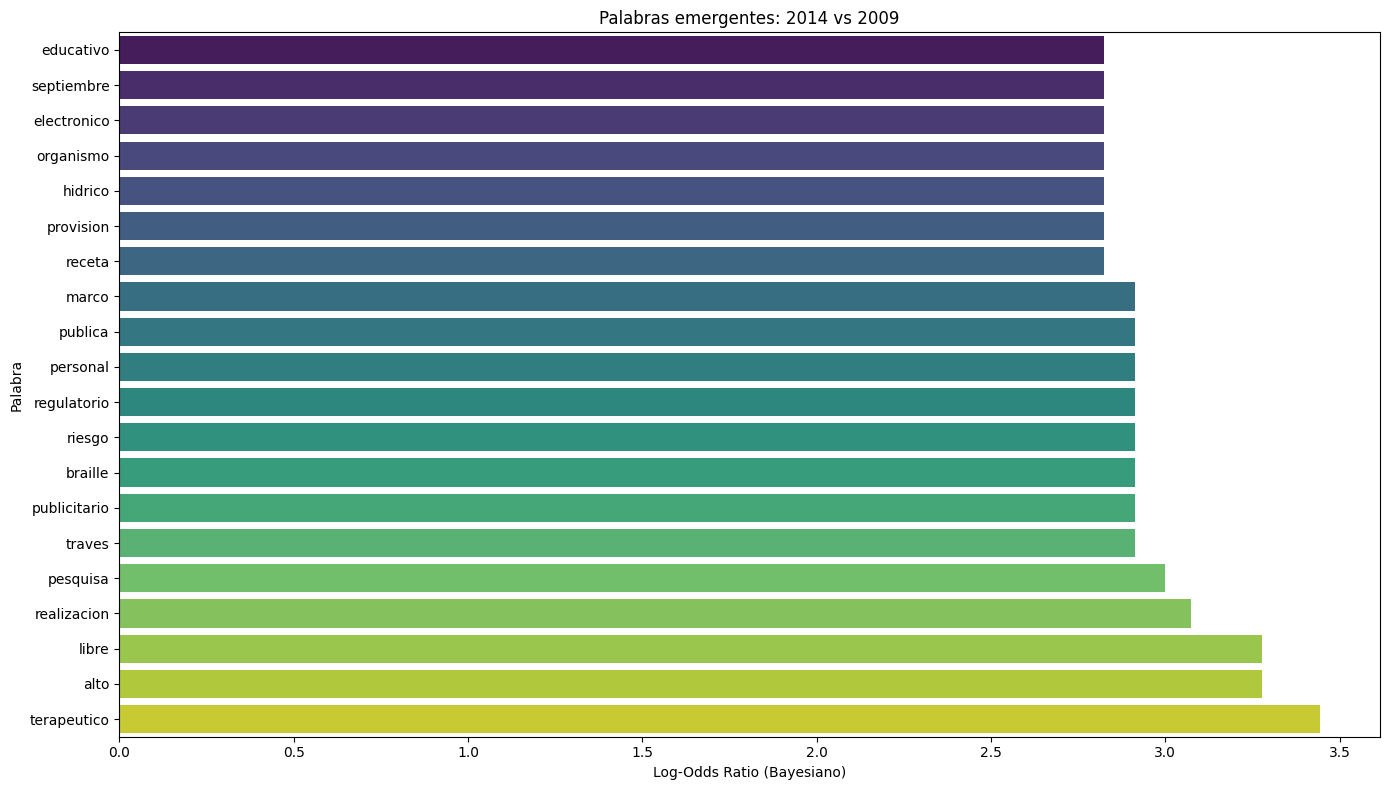

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\3425610404.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


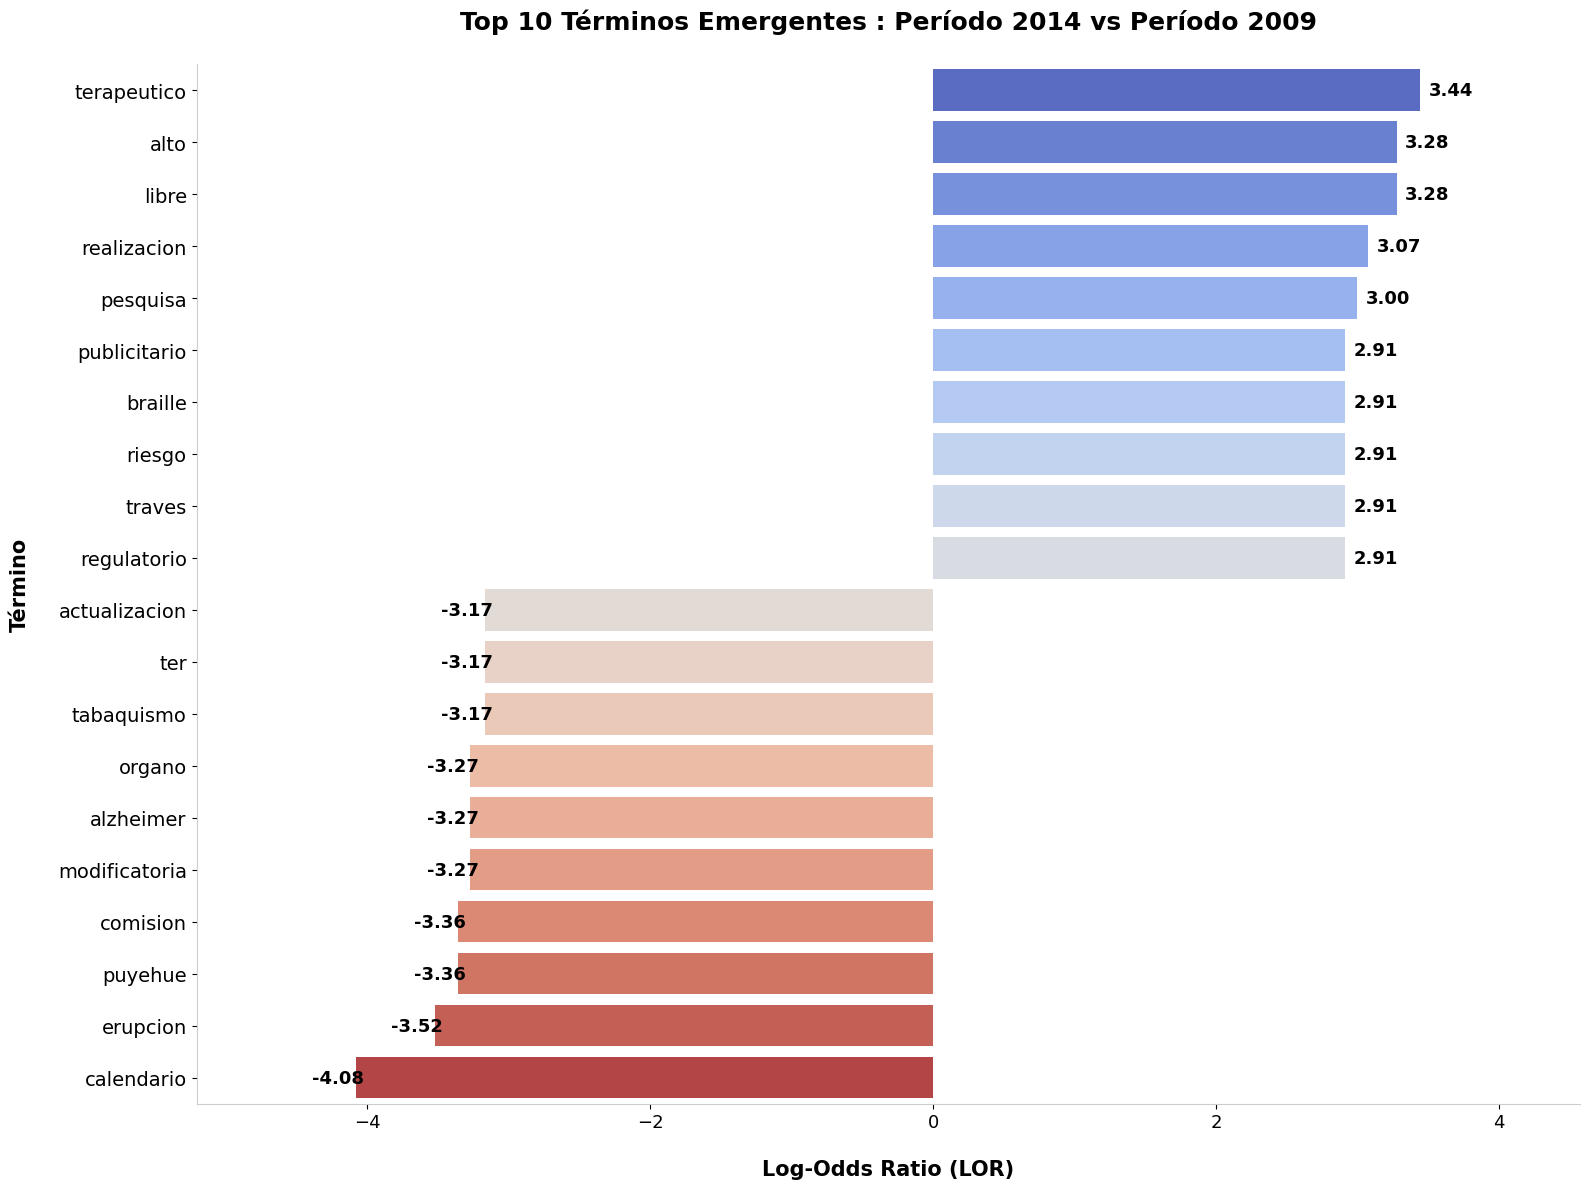


--- Comparación entre 2014 y 2019 ---
total 1 6984
total 2 7641
perceptil 90 2.6190661606462493
Cantidad de palabras emergentes : 46

--- Palabras emergentes en 2019 comparado con 2014 ---


,Frecuencia_2014,Frecuencia_2019,log_odds_ratio,es_emergente
Palabra,,,,
covid,0.0,104.0,5.266137,True
crear,0.0,53.0,4.589888,True
pandemia,0.0,47.0,4.470146,True
coronavirus,0.0,24.0,3.805065,True
acompanamiento,0.0,19.0,3.576151,True
plasma,0.0,15.0,3.346052,True
solar,0.0,14.0,3.279229,True
trabajador,0.0,14.0,3.279229,True
abordaje,0.0,13.0,3.207639,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\2009719689.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


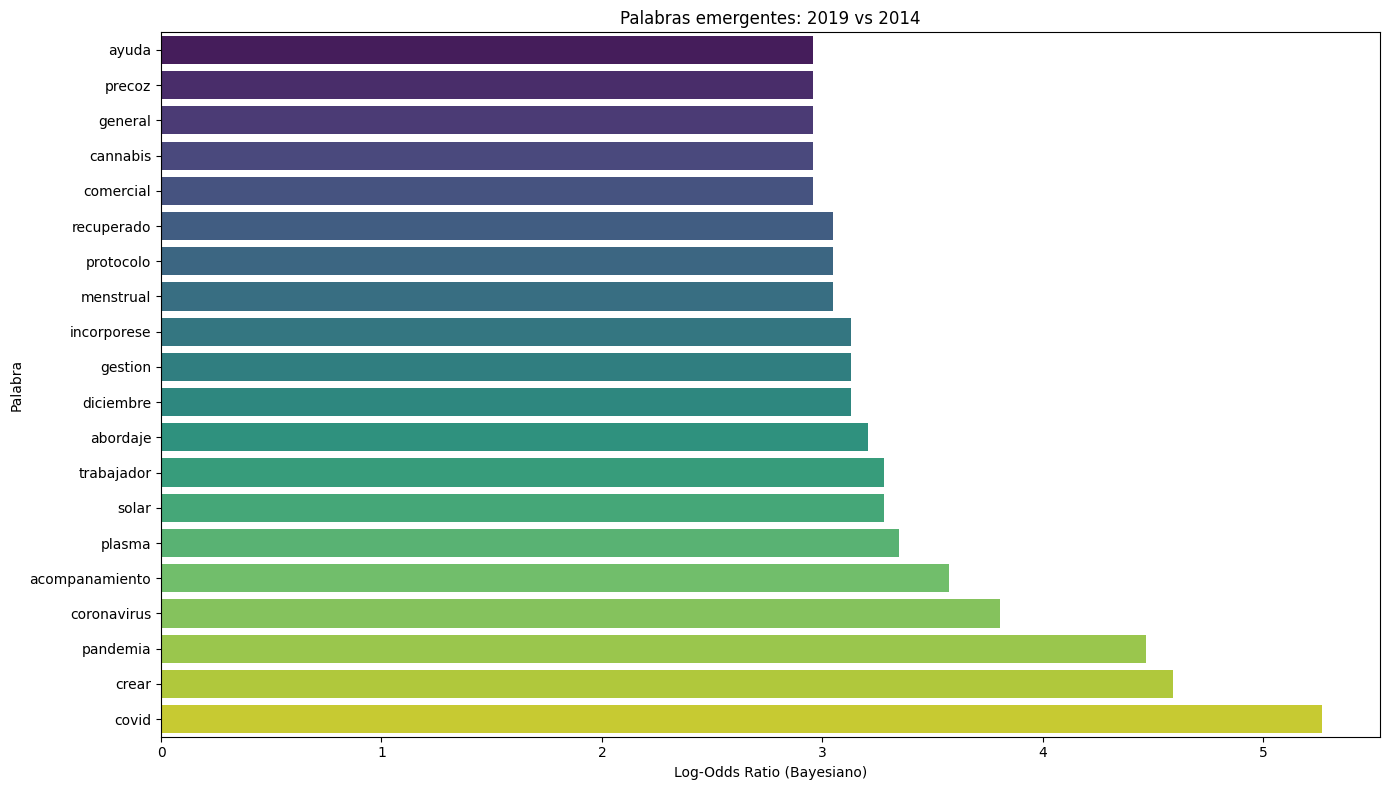

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\3425610404.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


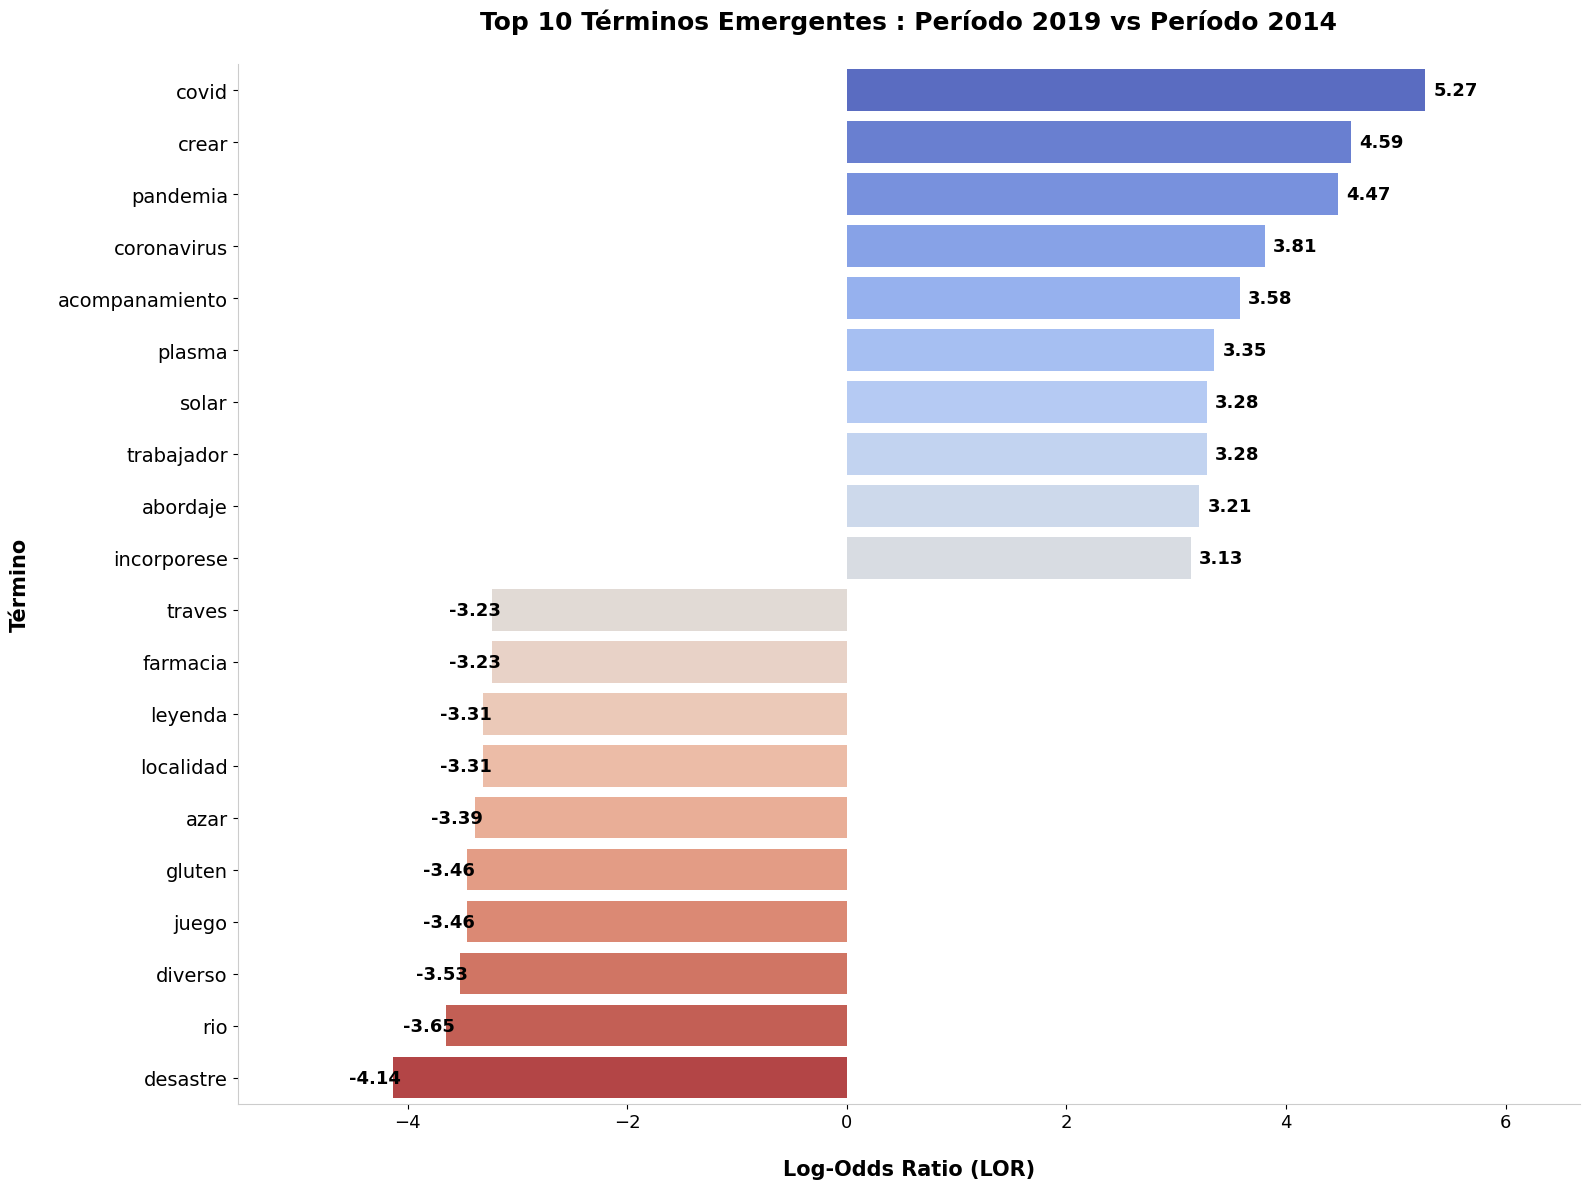


--- Comparación entre 2009 y 2019 ---
total 1 5589
total 2 7641
perceptil 90 2.632913371267788
Cantidad de palabras emergentes : 44

--- Palabras emergentes en 2019 comparado con 2009 ---


,Frecuencia_2009,Frecuencia_2019,log_odds_ratio,es_emergente
Palabra,,,,
covid,0.0,104.0,5.043334,True
crear,0.0,53.0,4.367085,True
pandemia,0.0,47.0,4.247342,True
personal,0.0,40.0,4.086993,True
marco,0.0,39.0,4.061861,True
endometriosis,0.0,32.0,3.865880,True
coronavirus,0.0,24.0,3.582262,True
terapeutico,0.0,24.0,3.582262,True
acompanamiento,0.0,19.0,3.353347,True


C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\2009719689.py:103: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='log_odds_ratio', y=top_emergentes.index, data=top_emergentes, palette='viridis')


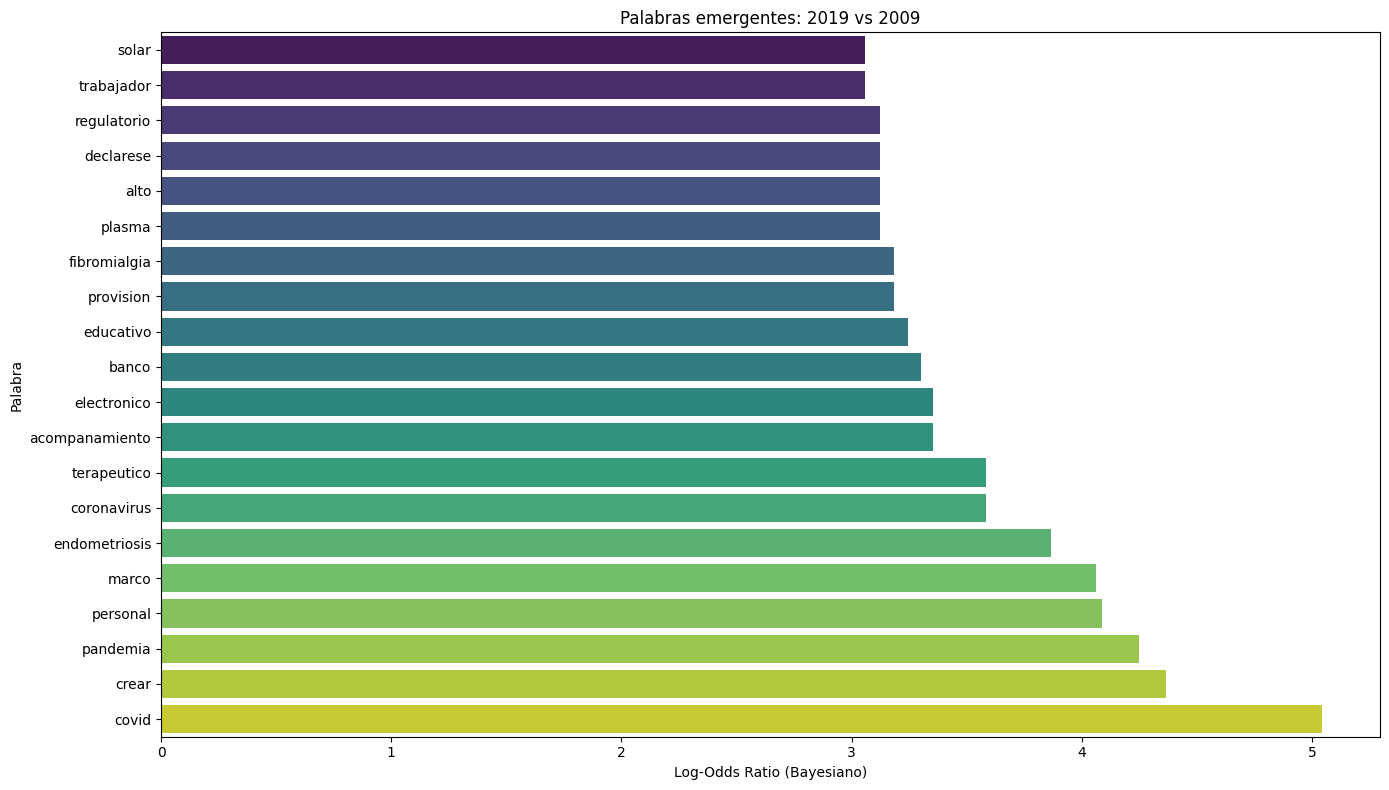

C:\Users\Usuario\AppData\Local\Temp\ipykernel_9000\3425610404.py:69: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


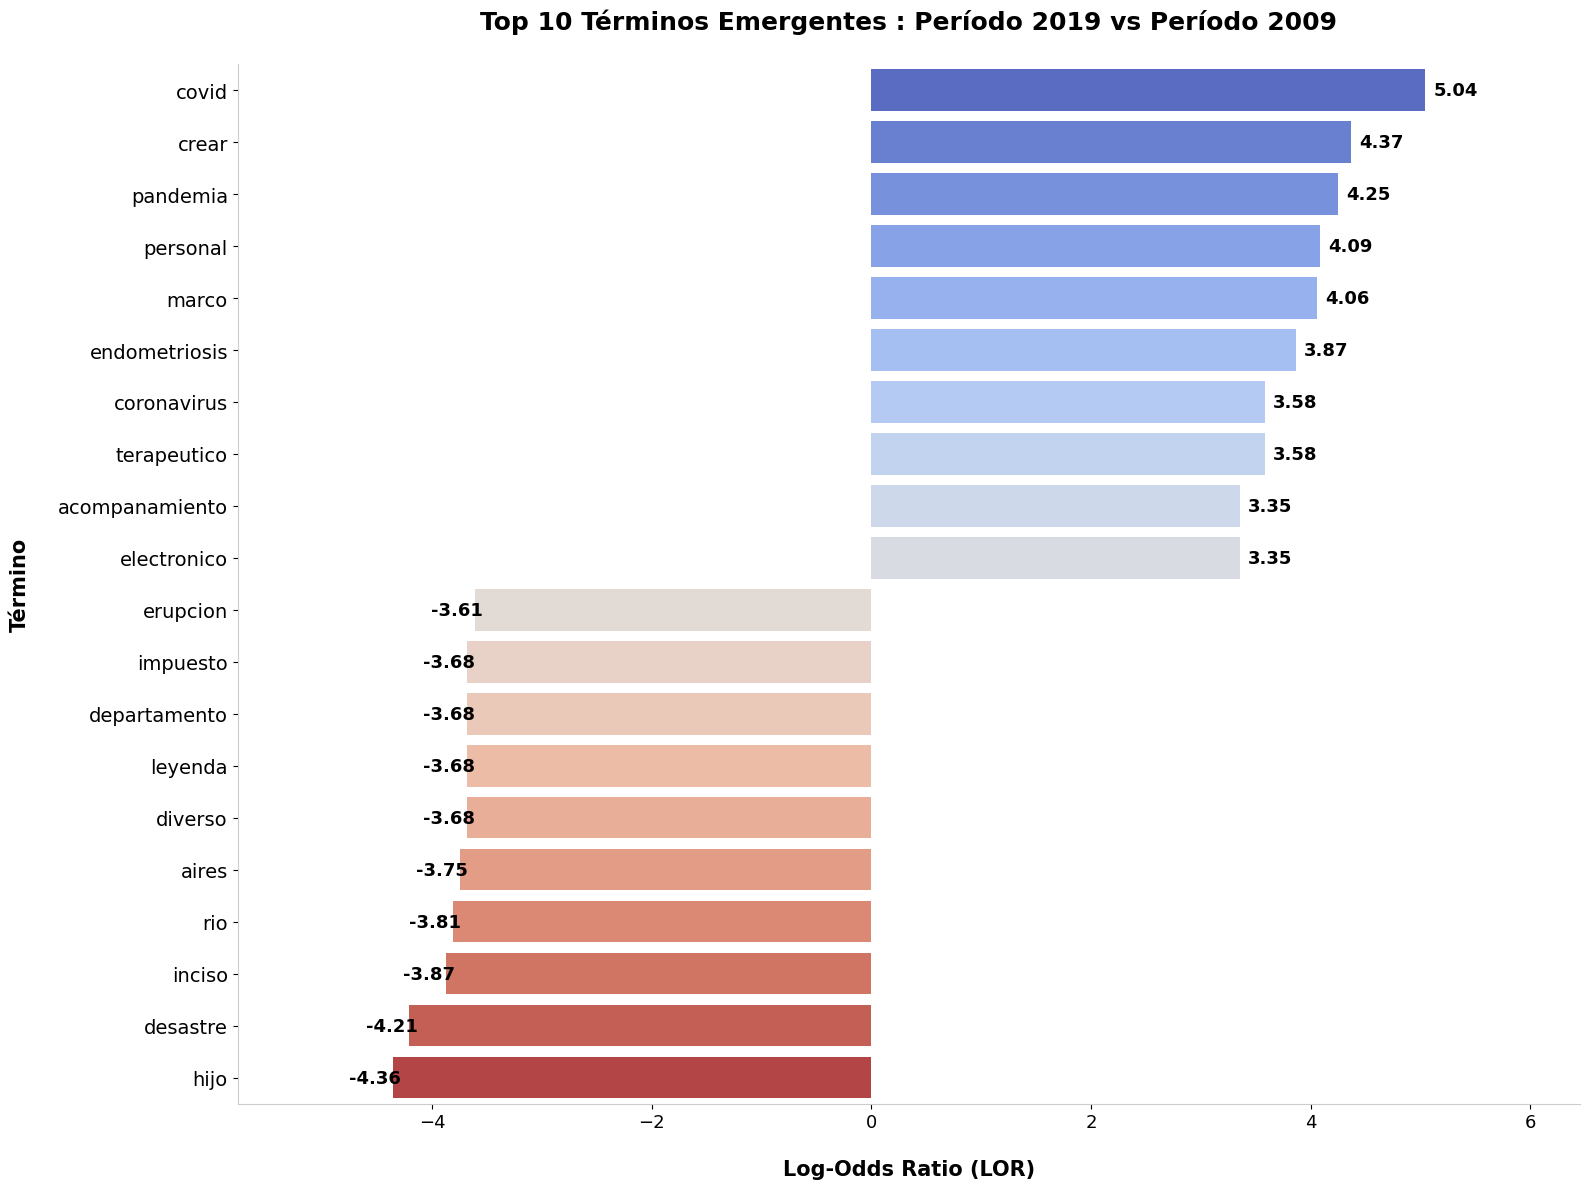

In [67]:
periodo_pares = [('2009', '2014'), ('2014', '2019'), ('2009', '2019')]
n = 10
for p1, p2 in periodo_pares:
    print(f"\n--- Comparación entre {p1} y {p2} ---")
    periodo_emergente = p2
    periodo_referencia = p1
    identificar_palabras_emergentes_lor

    resultados_emergentes = identificar_palabras_emergentes_lor(
        freqs_df.copy(), periodo_referencia, periodo_emergente, prior=0.5,  min_frecuencia=5 #  umbral_lor=0 # Consideramos regla basica
    )

    resultados_emergentes.to_csv(RESULTADOS_DIR+'/archivos_out/lor_'+p1+'_'+p2+'.csv')
    
    print("Cantidad de palabras emergentes :",len(resultados_emergentes[resultados_emergentes['es_emergente']==True]))
   
    #lor_df = identificar_lor(
    #    freqs_df.copy(), periodo_referencia, periodo_emergente, prior=0.5  )
    
    #visualizar_distribución(lor_df)
    print(f"\n--- Palabras emergentes en {periodo_emergente} comparado con {periodo_referencia} ---")
    
    display(resultados_emergentes.head(10))
    visualizar_palabras_emergentes_lor(resultados_emergentes, title=f"Palabras emergentes: {periodo_emergente} vs {periodo_referencia}")
    visualizar_top_odds_ratios(resultados_emergentes, 'log_odds_ratio', n=10, title=f"Top {n} Términos Emergentes : Período {periodo_emergente} vs Período { periodo_referencia}")


LOR > 0: Indica que la palabra tiene una mayor probabilidad de aparecer en el grupo 1 (generalmente el periodo de tiempo más reciente o el corpus de interés) en comparación con el grupo 2 (el periodo de referencia). Cuanto mayor sea el valor positivo, más fuerte es la evidencia de que la palabra está emergiendo o aumentando su uso en el grupo 1.

LOR < 0: Indica que la palabra tiene una menor probabilidad de aparecer en el grupo 1 en comparación con el grupo 2. Un valor negativo grande sugiere que la palabra está disminuyendo su uso o era más común en el grupo de referencia.


LOR ≈ 0: Indica que la probabilidad de la palabra es similar en ambos grupos. Estas palabras probablemente no son emergentes ni en declive significativo.

Se consider un prior pequeño y constante como 0.5. Esta es una práctica común. Habría que analizar otros.

* El análisis del log-odds ratio entre los períodos 2009 y 2014 revela la emergencia de nuevos términos asociados principalmente a la salud mental infantil (tdah, hiperactividad, déficit) y la salud reproductiva femenina (endometriosis, trombofilia) .
* La comparación entre los períodos 2014 y 2019 muestra palabras que influyen en un cambio semántico abrupto, vinculado principalmente a la pandemia de COVID-19. Palabras como “covid”, “pandemia” y “coronavirus” emergen con log-odds elevados, reflejando la centralidad de la crisis sanitaria en la agenda legislativa.


In [68]:
def mostrar_ejemplos_contextuales_titulos(df, palabra, periodo, n=5):
    """
    Muestra ejemplos de títulos que contienen una palabra específica en un periodo.

    Args:
        df (pd.DataFrame): DataFrame con columnas 'titulo' (o la columna de títulos) y 'periodo'.
        palabra (str): La palabra para buscar en los títulos (insensible a mayúsculas/minúsculas).
        periodo (int): El periodo de interés.
        n (int): Número de ejemplos a mostrar.
    """
    df_periodo = df[df['Periodo_5anios'] == periodo]
    titulos_con_palabra = df_periodo[
    df_periodo['Título normalizado']
    .str.lower()
    .str.contains(rf'\b{palabra.lower()}\b', regex=True, na=False)
    ]

    if not titulos_con_palabra.empty:
        print(f"\nEjemplos de títulos conteniendo '{palabra}' en el periodo {periodo}:")
        display(titulos_con_palabra[['Periodo_5anios','Año','Título','Título normalizado']].sort_values('Año').head(n))
    
    else:
        print(f"No se encontraron títulos conteniendo '{palabra}' en el periodo {periodo}.")

In [70]:
basetexto_df.columns
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'braille',2014, n=2)


Ejemplos de títulos conteniendo 'braille' en el periodo 2014:


,Periodo_5anios,Año,Título,Título normalizado
23330,2014,2014,"CODIGO ALIMENTARIO ARGENTINO, LEY 18284: MODIFICACION DEL CAPITULO V, SOBRE NORMAS PARA ROTULACION DE LOS ALIMENTOS. INCORPORACION DEL PUNDO D) (ROTULOS EN SISTEMA BRAILLE) (REPRODUCCION DEL EXPEDIENTE 0350-D-12).",codigo alimentario argentino capitulo norma rotulacion alimento incorporacion pundo rotulo sistema braille
20479,2014,2015,INDIVIDUALIZACION DE MEDICAMENTOS EN SISTEMA BRAILLE (REPRODUCCION DEL EXPEDIENTE 5081-D-13).,individualizacion medicamento sistema braille


In [71]:
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'terapeutico',2014, n=2)


Ejemplos de títulos conteniendo 'terapeutico' en el periodo 2014:


,Periodo_5anios,Año,Título,Título normalizado
23095,2014,2014,REGULACION DE LA EQUINOTERAPIA COMO ACTIVIDAD TERAPEUTICA DE HABILITACION Y REHABILITACION.,regulacion equinoterapia actividad terapeutico habilitacion rehabilitacion
21927,2014,2014,EJERCICIO PROFESIONAL DEL ACOMPAÑANTE TERAPEUTICO. REGIMEN.,ejercicio profesional acompanante terapeutico regimen


In [72]:
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'pesquisa',2014, n=2)



Ejemplos de títulos conteniendo 'pesquisa' en el periodo 2014:


,Periodo_5anios,Año,Título,Título normalizado
20680,2014,2014,"PESQUISA NEONATAL (LEY 26279). MODIFICACION DEL ARTICULO 1°, SOBRE INCORPORACION DE DIVERSOS ESTUDIOS EN LOS RECIEN NACIDOS.",pesquisa neonatal incorporacion diverso estudio recien nacido
21829,2014,2014,"PESQUISA NEONATAL - LEY 26279: MODIFICACION DEL ARTICULO 1, SOBRE INCORPORACION DE DIVERSOS ESTUDIOS EN LOS RECIEN NACIDOS.",pesquisa neonatal incorporacion diverso estudio recien nacido


In [45]:
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'puyehue',2009, n=2)



Ejemplos de títulos conteniendo 'puyehue' en el periodo 2009:


,Periodo_5anios,Año,Título,Título normalizado
27833,2009,2011,"ERUPCION DEL VOLCAN PUYEHUE: OTORGUESE A TODO JEFE O JEFA DE FAMILIA RURAL DEDICADA A LA CRIANZA DE OVINOS Y / O CAPRINOS EN CALIDAD DE MINIFUNDISTAS DE AREAS RURALES DE LA PROVINCIA DEL CHUBUT, UNA ASIGNACION MENSUAL EQUIVALENTE A UN SALARIO MINIMO, VITAL Y MOVIL, POR EL PLAZO DE UN AÑO CONTADO A PARTIR DEL 01 DE ENERO HASTA EL 31 DE DICIEMBRE DE 2012.",erupcion volcan puyehue otorguese jefe jefa familia rural dedicado crianza ovino caprino calidad minifundista area rural provincia chubut asignacion mensual equivalente salario minimo vital movil plazo ano contado enero diciembre
28103,2009,2011,"ERUPCION DEL VOLCAN PUYEHUE: DECLARAR ZONA DE DESASTRE Y EMERGENCIA ECONOMICA, SOCIAL Y PRODUCTIVA POR 180 DIAS PRORROGABLES, A LAS PROVINCIAS AFECTADAS.",erupcion volcan puyehue declarar zona desastre emergencia economico social productivo prorrogable provincia afectado


In [76]:
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'tabaquismo',2009, n=2)



Ejemplos de títulos conteniendo 'tabaquismo' en el periodo 2009:


,Periodo_5anios,Año,Título,Título normalizado
29249,2009,2010,"TABAQUISMO, LEY 23344: MODIFICACION DEL ARTICULO 1, SOBRE EXHIBICION DE LA LEYENDA ""EL FUMAR ES PERJUDICIAL PARA LA SALUD"" EN LOS ENVASES EN QUE SE COMERCIALICEN TABACOS, CIGARRILLOS, CIGARROS Y OTROS PRODUCTOS DESTINADOS A FUMAR.",tabaquismo exhibicion leyenda fumar perjudicial salud envase comercialicir tabaco cigarrillo cigarro producto destinado fumar
29465,2009,2010,"TABAQUISMO - LEY 23344: INCORPORACION DEL ARTICULO 2 BIS, SOBRE EXHIBICION DE LA LEYENDA ""FUMAR ES PERJUDICIAL PARA LA SALUD"" EN ESCENAS TELEVISIVAS Y/O CINEMATOGRAFICAS DONDE SE CONSUMA PRODUCTOS ELABORADOS CON TABACO.",tabaquismo ley exhibicion leyenda fumar perjudicial salud escena televisivo cinematografica consumar producto elaborado tabaco


In [47]:
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'neuquen',2014, n=2)



Ejemplos de títulos conteniendo 'neuquen' en el periodo 2014:


,Periodo_5anios,Año,Título,Título normalizado
22560,2014,2014,"DIVERSOS DEPARTAMENTOS DE LAS PROVINCIAS DE RIO NEGRO Y DEL NEUQUEN. SE LOS DECLARA ZONA DE DESASTRE Y EMERGENCIA ECONOMICA Y SOCIAL Y MEDIOAMBIENTAL POR EL PLAZO DE 120 DIAS PRORROGABLES, COMO CONSECUENCIA DEL TEMPORAL OCURRIDO DEL 2 AL 10 DE ABRIL DE 2014.",diverso departamento provincia rio negro neuquen declarar zona desastre emergencia economico social medioambiental plazo prorrogable consecuencia temporal ocurrido abril
22658,2014,2014,"PROVINCIA DEL NEUQUEN: SE LA DECLARA ZONA DE DESASTRE Y EMERGENCIA SOCIAL POR EL PLAZO DE 180 DIAS PRORROGABLES, POR EL TEMPORAL REGISTRADO EN EL MES DE ABRIL DE 2014.",provincia neuquen declarar zona desastre emergencia social plazo prorrogable temporal registrado mes abril


In [48]:
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'agropecuario',2014, n=2)



Ejemplos de títulos conteniendo 'agropecuario' en el periodo 2014:


,Periodo_5anios,Año,Título,Título normalizado
19081,2014,2015,"DIVERSAS LOCALIDADES DE LA PROVINCIA DE BUENOS AIRES. SE LAS DECLARA ZONA DE DESASTRE Y EN EMERGENCIA HIDRICA, ECONOMICA, SOCIAL Y AGROPECUARIA POR EL TERMINO DE 180 DIAS PRORROGABLES",diverso localidad provincia aires declarar zona desastre emergencia hidrico economico social agropecuario termino prorrogable
19562,2014,2015,"DECLARAR ZONA DE DESASTRE Y EMERGENCIA ECONOMICA, SOCIAL, PRODUCTIVA, AGROPECUARIA Y TURISTICA POR EL TERMINO DE 180 DIAS PRORROGABLES A LAS PROVINCIAS DE RIO NEGRO Y DEL NEUQUEN, POR LA ERUPCION DEL VOLCAN CALBUCO DE LA REPUBLICA DE CHILE.",declarar zona desastre emergencia economico social productivo agropecuario turistico termino prorrogable provincia rio negro neuquen erupcion volcan calbuco republica chile


In [49]:
mostrar_ejemplos_contextuales_titulos(basetexto_df, 'plasma',2019, n=2)



Ejemplos de títulos conteniendo 'plasma' en el periodo 2019:


,Periodo_5anios,Año,Título,Título normalizado
6471,2019,2020,CREASE EL PROGRAMA DE INCENTIVO PARA LA DONACION DE PLASMA SANGUINEO.,crear programa incentivo donacion plasma sanguineo
6631,2019,2020,CONSENTIMIENTO PRESUNTO DE DONACION DE PLASMA DE PACIENTES RECUPERADOS DE COVID-19.,consentimiento presunto donacion plasma paciente recuperado covid


##### TF-IDF por período 

In [50]:
docs_por_periodo = pd.Series(PER5anios_df['Título normalizado'].values, index =PER5anios_df['Periodo_5anios'])
#docs_por_periodo

In [51]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer


# Aplicamos TF-IDF
vectorizer = TfidfVectorizer()
tfidf_matrix = vectorizer.fit_transform(docs_por_periodo)

# Creamos un DataFrame con los resultados
tfidf_df = pd.DataFrame(tfidf_matrix.T.toarray(), 
                        index=vectorizer.get_feature_names_out(), 
                        columns=docs_por_periodo.index)

# Mostrar las top palabras distintivas por período
for periodo in tfidf_df.columns:
    print(f"\n Palabras más distintivas en {periodo}")
    display(tfidf_df[periodo].sort_values(ascending=False).head(10))


 Palabras más distintivas en 2009


nacional       0.401848
creacion       0.303318
salud          0.256951
programa       0.216380
social         0.212516
regimen        0.204788
ley            0.197060
obligatorio    0.162285
medico         0.150693
declarar       0.150693
Name: 2009, dtype: float64


 Palabras más distintivas en 2014


nacional       0.416052
creacion       0.341535
regimen        0.315144
programa       0.256151
salud          0.240627
medico         0.187844
obligatorio    0.150586
social         0.142824
persona        0.139719
tratamiento    0.138166
Name: 2014, dtype: float64


 Palabras más distintivas en 2019


nacional       0.475198
creacion       0.331319
programa       0.278519
salud          0.257399
covid          0.232434
regimen        0.232319
persona        0.143879
medico         0.143879
obligatorio    0.139919
integral       0.135959
Name: 2019, dtype: float64

Se aplicó la métrica TF-IDF sobre los textos agrupados por períodos de 5 años, considerando cada período como un “documento agregado”. Esta estrategia permitió identificar términos con alta relevancia local, palabras distintivas que caracterizan el discurso legislativo sobre salud en cada período analizado.